# Perch V2 — Zero-Shot vs Trained Classifier Evaluation

### Data format expected
- **WAV folder**: flat folder of `.wav` files named like `SCW1807_20200711_082500.wav`
- **Annotation JSON**: single JSON file mapping `SCW1807_20200711_082500-contours.json` → list of `{start, end, label}` dicts

### What this notebook does

1. Extracts **fixed 5s windows** and associates the corresponding labels
2. Embeds all windows with **Perch V2**
3. Evaluates **zero-shot** performance using Perch V2's built-in logits
4. Trains a **linear classifier** on top of the embeddings
5. Reports **per-class precision / recall / F1** for both, with plots
6. Performs **Dimensinality Reduction** to asses class separation in 2D and cluster formation.


> **Requirements**: GPU runtime + perch-hoplite installed (cells below)

In order to use Perch V2, you must install this version (or later) of TensorFlow and cuda

In [ ]:
%pip install tensorflow[and-cuda]~=2.20.0rc0

Choose the working gpu

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
import tensorflow as tf
import torch

print(f"TF GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"PyTorch: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Only use GPU 0
    tf.config.set_visible_devices(gpus[0], 'GPU')
    # Optional: prevent TF from grabbing all memory
    tf.config.experimental.set_memory_growth(gpus[0], True)
print(f"TF using: {tf.config.get_visible_devices('GPU')}")

2026-04-29 10:59:53.129170: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 10:59:53.182032: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-29 10:59:54.555851: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PyTorch: NVIDIA L4
TF using: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#@title Imports
import json
import warnings
from pathlib import Path
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report
)
import librosa.display
import soxr
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from perch_hoplite.zoo import model_configs

In [4]:
#@title Configuration { vertical-output: true }

#@markdown Folder containing all .wav files
wav_folder = '/data2/mromaniuc/cet-det/datasets/MONISH'  #@param {type:'string'}

#@markdown Folder for base saving
save_dir = '/data2/mromaniuc/cet-det/models/perch_v2/MONISH'

#@markdown Window size in seconds fed to Perch V2 (default 5.0)
window_size_s = 5.0  #@param {type:'number'}

#@markdown Minimum overlap (s) between an annotation and a window to label it as positive
min_overlap_s = 0.001  #@param {type:'number'}

#@markdown Fraction of data held out for testing
test_size = 0.3  #@param {type:'number'}

#@markdown Random seed
random_seed = 123  #@param {type:'number'}

In [5]:
#@title Load Perch V2 model
model_key = 'perch_v2'
embedding_model = model_configs.load_model_by_name(model_key)
sr = embedding_model.sample_rate

perch_class_names = list(embedding_model.class_list['labels'].classes)
print(f'Model loaded. Sample rate: {sr} Hz')
print(f'Perch V2 built-in classes: {len(perch_class_names)}')

I0000 00:00:1777453207.973541 3368639 gpu_device.cc:2020] Created device /device:GPU:0 with 967 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9


I0000 00:00:1777453208.364775 3368639 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 967 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9


Model loaded. Sample rate: 32000 Hz
Perch V2 built-in classes: 14795


Found 6 species folders


100%|██████████| 6/6 [00:00<00:00, 409.83it/s]


=== Global Summary (211 files) ===
Min:    0.057s
Max:    265.054s
Mean:   13.008s
Median: 3.797s

=== Proportion by length (global) ===
  <  1.00s :    26 (12.3%)
  <  2.00s :    56 (26.5%)
  <  3.00s :    85 (40.3%)
  <  3.75s :   103 (48.8%)
  <  5.00s :   129 (61.1%)
  < 10.00s :   182 (86.3%)
  >= 5.00s :    82 (38.9%)

=== Per-species summary ===
                            count   mean  median   min     max
species                                                       
Balaenoptera_acutorostrata     14   0.10    0.11  0.06    0.11
Balaenoptera_physalus          40   1.83    1.64  0.22    3.82
Globicephala_melas             56  35.22    7.23  0.51  265.05
Grampus_griseus                54   8.33    3.51  1.27   91.20
Orcinus_orca                   28   4.95    3.94  1.43   19.50
Tursiops_truncatus             19   5.78    5.76  2.91    9.60

=== Sample rates ===
file_sr                     16000
species                          
Balaenoptera_acutorostrata     14
Balaenoptera_phy

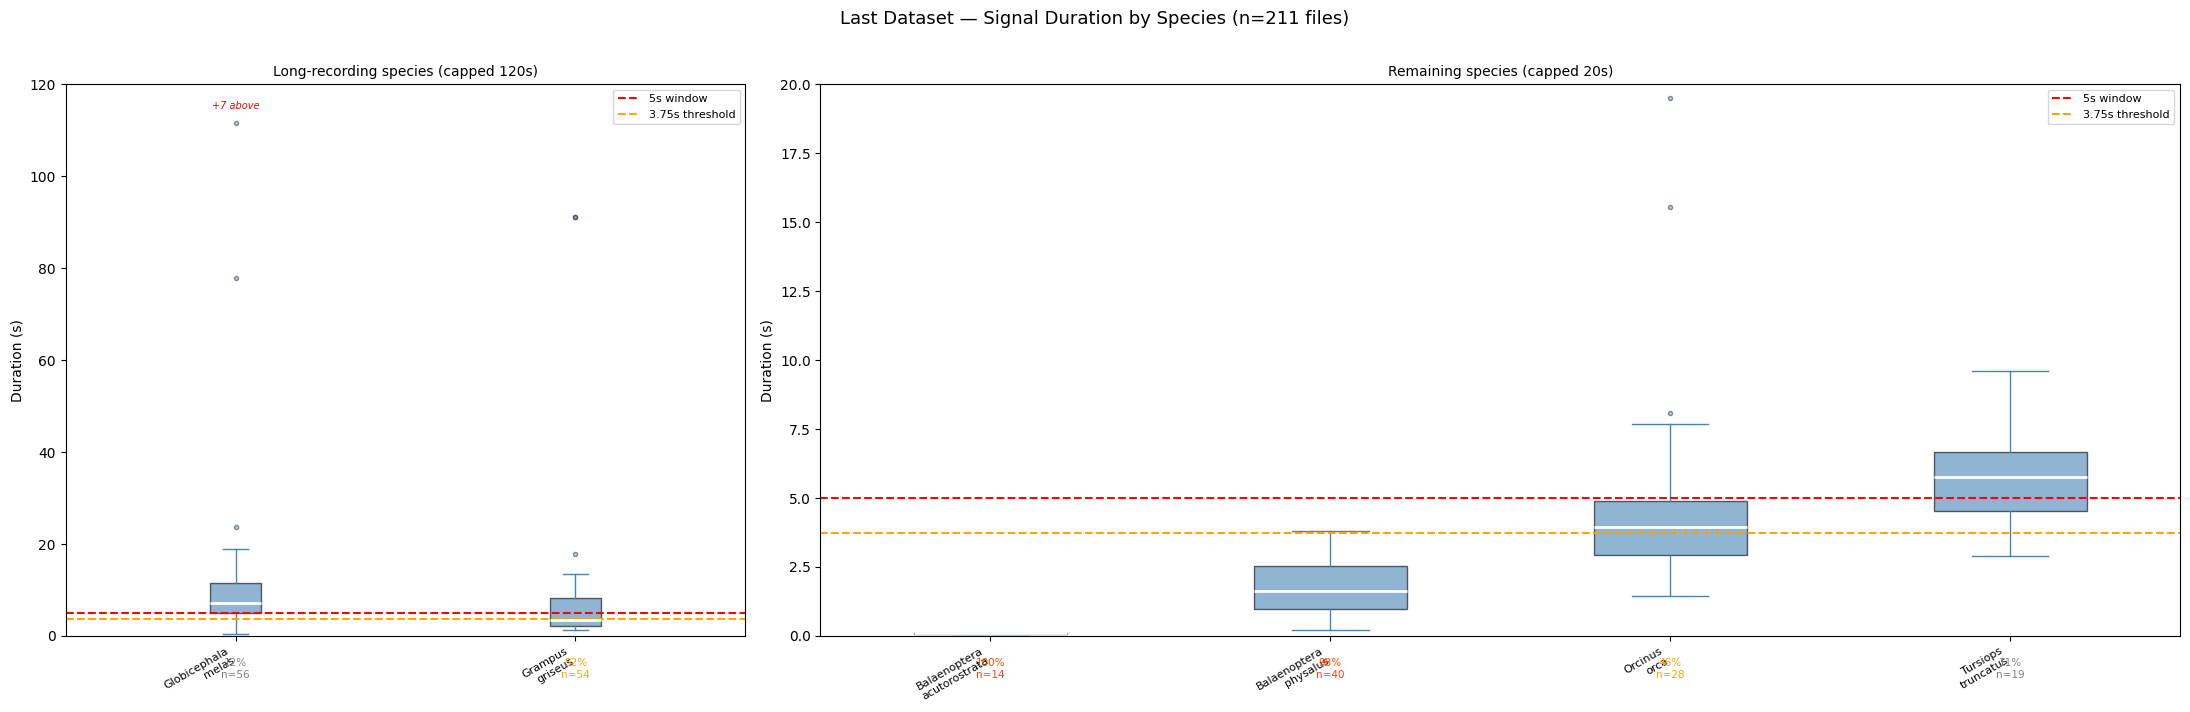

Saved: figures/last_dataset_duration_boxplots.png


In [6]:
#@title Duration Distribution — Last Dataset (split boxplots)
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from pathlib import Path
from tqdm import tqdm
import pandas as pd

# ── Collect durations ─────────────────────────────────────────────────────────
wav_folder_path = Path(wav_folder)
species_dirs    = sorted([d for d in wav_folder_path.iterdir() if d.is_dir()])
print(f'Found {len(species_dirs)} species folders')

records = []
for species_dir in tqdm(species_dirs):
    species   = species_dir.name
    wav_files = sorted(list(species_dir.glob('*.wav')) + list(species_dir.glob('*.WAV')))
    for wf in wav_files:
        try:
            info = sf.info(str(wf))
            records.append({
                'species':    species,
                'duration_s': info.duration,
                'file_sr':    info.samplerate,
                'file':       wf.name
            })
        except Exception as e:
            print(f'  Error {wf.name}: {e}')

df = pd.DataFrame(records)

# ── Global summary ────────────────────────────────────────────────────────────
print(f'\n=== Global Summary ({len(df)} files) ===')
print(f'Min:    {df.duration_s.min():.3f}s')
print(f'Max:    {df.duration_s.max():.3f}s')
print(f'Mean:   {df.duration_s.mean():.3f}s')
print(f'Median: {df.duration_s.median():.3f}s')

print(f'\n=== Proportion by length (global) ===')
for t in [1, 2, 3, 3.75, 5, 10]:
    n = (df.duration_s < t).sum()
    print(f'  < {t:5.2f}s : {n:5d} ({100*n/len(df):.1f}%)')
n = (df.duration_s >= 5).sum()
print(f'  >= 5.00s : {n:5d} ({100*n/len(df):.1f}%)')

print(f'\n=== Per-species summary ===')
per_species = df.groupby('species')['duration_s'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)
print(per_species.round(2).to_string())

print(f'\n=== Sample rates ===')
print(df.groupby(['species', 'file_sr']).size().unstack(fill_value=0).to_string())

# ── Decide groups based on distribution ──────────────────────────────────────
# We'll plot all species first in one pass, then you tell me which to split
species_list = sorted(df['species'].unique())
data_by_sp   = {s: df[df['species'] == s]['duration_s'].values for s in species_list}

# auto-detect long-tailed species (max > 30s) for splitting
group_long = [s for s in species_list if data_by_sp[s].max() > 30]
group_rest = [s for s in species_list if s not in group_long]

print(f'\nAuto-detected long-tailed species (max > 30s): {group_long}')
print(f'Remaining species: {group_rest}')

def plot_boxes(ax, species_subset, title, y_max=None):
    data   = [data_by_sp[s] for s in species_subset]
    labels = [s.replace('_', '\n') for s in species_subset]

    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2),
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    whiskerprops=dict(color='steelblue'),
                    capprops=dict(color='steelblue'),
                    flierprops=dict(marker='o', markersize=3,
                                    markerfacecolor='steelblue',
                                    alpha=0.4, linestyle='none'))

    ax.axhline(y=5,    color='red',    linestyle='--',
               linewidth=1.5, label='5s window')
    ax.axhline(y=3.75, color='orange', linestyle='--',
               linewidth=1.5, label='3.75s threshold')

    for i, (s, vals) in enumerate(zip(species_subset, data)):
        pct   = 100 * np.mean(vals < 3.75)
        color = 'orangered' if pct > 70 else 'orange' if pct > 30 else 'gray'
        ax.text(i + 1, -0.04, f'{pct:.0f}%\nn={len(vals)}',
                ha='center', va='top', fontsize=7.5, color=color,
                transform=ax.get_xaxis_transform())

        if y_max:
            n_clip = (vals > y_max).sum()
            if n_clip > 0:
                ax.text(i + 1, y_max * 0.97, f'+{n_clip} above',
                        ha='center', va='top', fontsize=7,
                        color='red', style='italic')

    ax.set_xticks(range(1, len(species_subset) + 1))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Duration (s)')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(bottom=0, top=y_max)

# ── Plot ──────────────────────────────────────────────────────────────────────
if group_long and group_rest:
    n_panels    = 2
    width_ratios = [len(group_long), len(group_rest)]
    fig, axes   = plt.subplots(1, 2, figsize=(22, 7),
                               gridspec_kw={'width_ratios': width_ratios})
    plot_boxes(axes[0], group_long,
               f'Long-recording species (capped 120s)', y_max=120)
    plot_boxes(axes[1], group_rest,
               f'Remaining species (capped 20s)',       y_max=20)
else:
    fig, ax = plt.subplots(figsize=(max(14, len(species_list) * 1.5), 7))
    plot_boxes(ax, species_list, 'All species (capped 20s)', y_max=20)

plt.suptitle(
    f'Last Dataset — Signal Duration by Species (n={len(df)} files)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('figures/last_dataset_duration_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/last_dataset_duration_boxplots.png')

We will drop baleane aucoustrata, we have maximum 0.1 seconds of signal, we cannot train on >90% synthetic data

Found 6 species folders
Excluding: {'Balaenoptera_acutorostrata'}


Species:   0%|          | 0/6 [00:00<?, ?it/s]

Species: 100%|██████████| 6/6 [00:16<00:00,  2.72s/it]



Total 5s windows : 617
Species          : 5
Excluded         : ['Balaenoptera_acutorostrata']
Skipped files    : 12

=== Windows per species ===
species
Globicephala_melas       410
Grampus_griseus          113
Orcinus_orca              37
Balaenoptera_physalus     29
Tursiops_truncatus        28

=== Window kind breakdown ===
window_kind            extended  real  tail_extended
species                                             
Balaenoptera_physalus        29     0              0
Globicephala_melas           13   368             29
Grampus_griseus              33    62             18
Orcinus_orca                 21    11              5
Tursiops_truncatus            7    12              9

Saved → models/perch_v2/LAST/windows_df.pkl


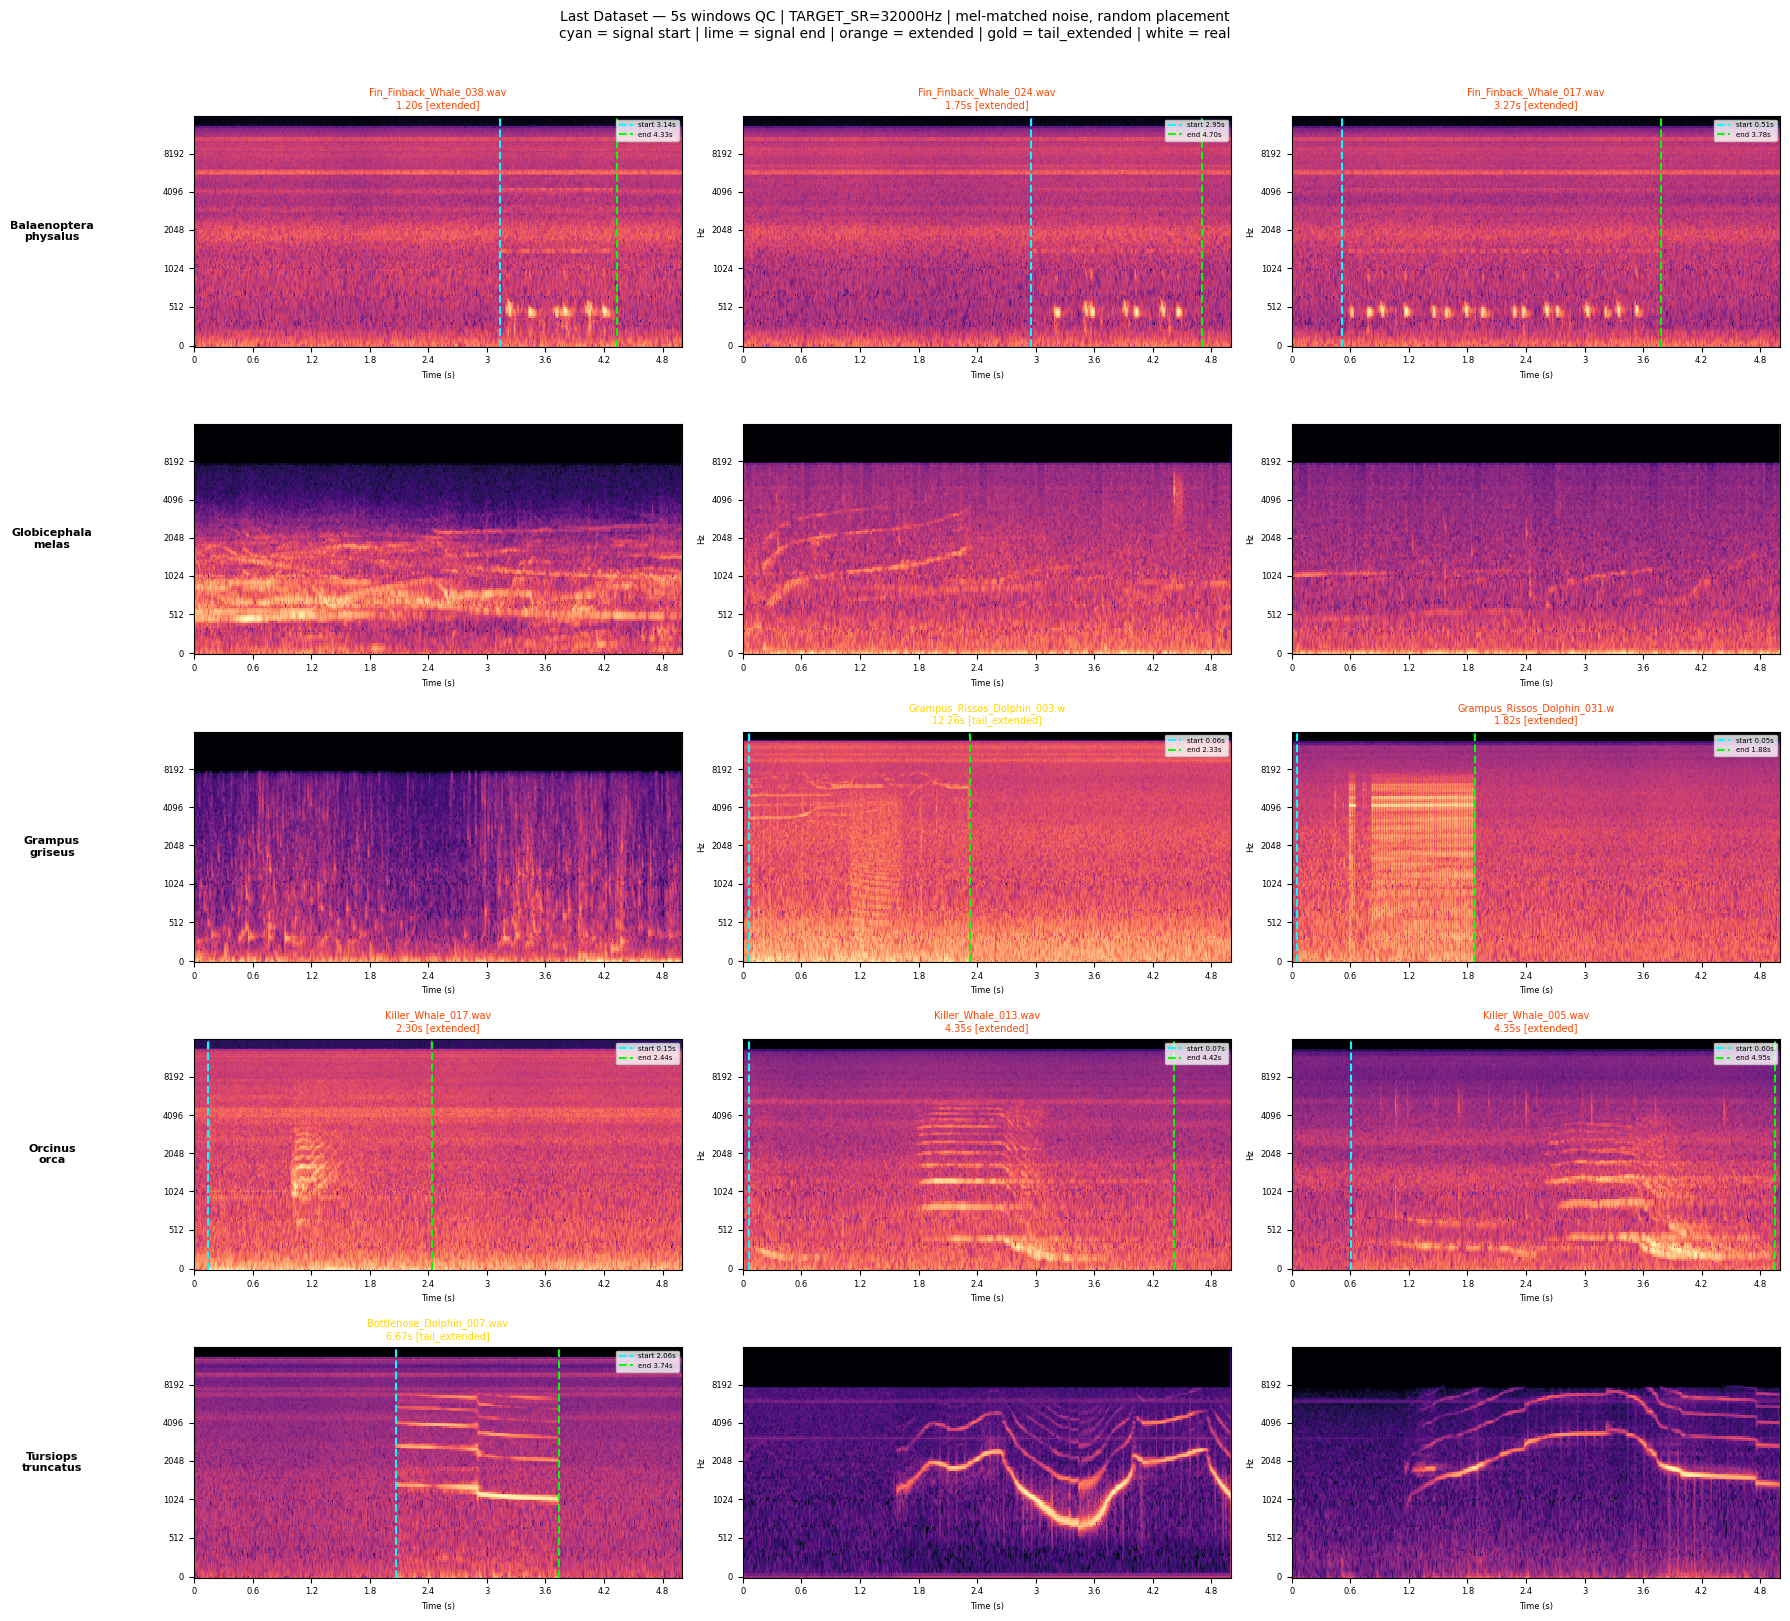

Saved: figures/last_dataset_spectrogram_qc.png


In [23]:
#@title Build windows, QC spectrograms, save windows to disk — Last Dataset
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
import soxr
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import random

TARGET_SR         = 32000
TARGET_SAMPLES    = int(5.0 * TARGET_SR)  # 160000
MIN_TAIL_SEC      = 1.0
WINDOWS_SAVE_PATH = 'models/perch_v2/LAST/windows_df.pkl'

np.random.seed(42)
random.seed(42)

EXCLUDE_SPECIES = {
    'Balaenoptera_acutorostrata',  # max 0.11s — only 2.2% real signal in a 5s window
}

# ── Slow amplitude drift ──────────────────────────────────────────────────────
def apply_slow_drift(signal, strength=0.15):
    n      = len(signal)
    n_ctrl = max(10, n // (TARGET_SR // 2))
    ctrl   = np.random.uniform(1.0 - strength, 1.0 + strength, n_ctrl)
    return (signal * np.interp(
        np.linspace(0, 1, n),
        np.linspace(0, 1, n_ctrl),
        ctrl
    )).astype(np.float32)

# ── Mel-space noise estimation ────────────────────────────────────────────────
def estimate_noise_mel(audio_raw, sr, n_mels=128, noise_floor_percentile=20):
    S            = librosa.feature.melspectrogram(
        y=audio_raw, sr=sr, n_mels=n_mels,
        hop_length=160, n_fft=1024, power=2.0
    )
    frame_energy = S.mean(axis=0)
    threshold    = np.percentile(frame_energy, noise_floor_percentile)
    quiet_idx    = frame_energy <= threshold
    if np.sum(quiet_idx) < 5:
        quiet_idx[:] = True
    mel_profile  = np.mean(S[:, quiet_idx], axis=1)
    rms_noise    = np.sqrt(np.mean(
        audio_raw[:int(np.sum(quiet_idx) * 160)] ** 2
    ))
    return mel_profile, rms_noise

# ── Fast FFT-based spectral noise synthesis ───────────────────────────────────
def generate_mel_matched_noise(mel_profile, rms_noise, length, sr):
    """
    Fast spectral shaping via FFT — no Griffin-Lim, no iterative inversion.
    """
    frame_len  = 1024
    hop        = frame_len // 2
    n_frames   = int(np.ceil(length / hop)) + 2
    output     = np.zeros(n_frames * hop + frame_len, dtype=np.float32)
    window     = np.hanning(frame_len).astype(np.float32)

    # interpolate mel profile (128 bins) to FFT bins (513)
    fft_bins   = frame_len // 2 + 1
    mel_interp = np.interp(
        np.linspace(0, 1, fft_bins),
        np.linspace(0, 1, len(mel_profile)),
        mel_profile
    ).astype(np.float32)
    mel_interp = np.sqrt(mel_interp + 1e-8)

    for i in range(n_frames):
        white     = np.random.randn(frame_len).astype(np.float32)
        X         = np.fft.rfft(white)
        X_shaped  = mel_interp * np.exp(1j * np.angle(X))
        frame     = np.fft.irfft(X_shaped).astype(np.float32)
        frame_rms = np.sqrt(np.mean(frame ** 2))
        if frame_rms > 0:
            frame *= (rms_noise / frame_rms)
        output[i * hop:i * hop + frame_len] += frame * window

    noise = output[:length]
    return apply_slow_drift(noise.astype(np.float32))

# ── Extend short signal into noise background ─────────────────────────────────
def extend_to_length(audio_raw, target_len,
                     noise_floor_percentile=20, fade_samples=320,
                     mel_profile=None, rms_noise=None):
    n = len(audio_raw)
    if n >= target_len:
        chunk = audio_raw[:target_len]
        peak  = np.max(np.abs(chunk))
        if peak > 0:
            chunk = chunk / peak * 0.95
        return chunk.astype(np.float32), 0

    if mel_profile is None or rms_noise is None:
        mel_profile, rms_noise = estimate_noise_mel(
            audio_raw, TARGET_SR,
            noise_floor_percentile=noise_floor_percentile
        )

    background = generate_mel_matched_noise(mel_profile, rms_noise, target_len, TARGET_SR)

    max_start  = target_len - n
    start      = np.random.randint(0, max_start + 1)
    fade       = min(fade_samples, n // 4,
                     max(start, 1), max(target_len - (start + n), 1))
    sig        = audio_raw.copy()

    if fade > 1:
        t                                = np.linspace(0.0, 1.0, fade, dtype=np.float32)
        background[start:start + fade]  *= (1.0 - t)
        sig[:fade]                      *= t
        sig[-fade:]                     *= (1.0 - t)
        background[start+n-fade:start+n] *= t

    output = background.copy()
    output[start:start + n] += sig
    peak   = np.max(np.abs(output))
    if peak > 0:
        output = output / peak * 0.95
    return output.astype(np.float32), start

# ── Windowing — compute noise profile once per file ───────────────────────────
def file_to_windows(audio_raw, target_len, min_tail_samples):
    n = len(audio_raw)

    # compute mel profile ONCE per file — reused for all windows
    mel_profile, rms_noise = estimate_noise_mel(audio_raw, TARGET_SR)

    if n < target_len:
        window, start = extend_to_length(
            audio_raw, target_len,
            mel_profile=mel_profile, rms_noise=rms_noise
        )
        return [(window, start, n)], ['extended']

    windows, kinds = [], []
    n_full = n // target_len
    for i in range(n_full):
        chunk = audio_raw[i * target_len:(i + 1) * target_len].copy()
        peak  = np.max(np.abs(chunk))
        if peak > 0:
            chunk = chunk / peak * 0.95
        windows.append((chunk.astype(np.float32), 0, target_len))
        kinds.append('real')

    tail = audio_raw[n_full * target_len:]
    if len(tail) >= min_tail_samples:
        window, start = extend_to_length(
            tail, target_len,
            mel_profile=mel_profile, rms_noise=rms_noise
        )
        windows.append((window, start, len(tail)))
        kinds.append('tail_extended')

    return windows, kinds

# ── Build windows_df ──────────────────────────────────────────────────────────
wav_folder_path  = Path(wav_folder)
species_dirs     = sorted([d for d in wav_folder_path.iterdir() if d.is_dir()])
min_tail_samples = int(MIN_TAIL_SEC * TARGET_SR)
windows_list     = []
skipped_files    = []
excluded_species = []

print(f'Found {len(species_dirs)} species folders')
print(f'Excluding: {EXCLUDE_SPECIES}')

for species_dir in tqdm(species_dirs, desc='Species'):
    species = species_dir.name

    if species in EXCLUDE_SPECIES:
        excluded_species.append(species)
        continue

    wav_files = sorted(
        list(species_dir.glob('*.wav')) + list(species_dir.glob('*.WAV'))
    )
    for wf in tqdm(wav_files, desc=species, leave=False):
        try:
            audio_raw, file_sr = sf.read(str(wf), always_2d=False)
            if audio_raw.ndim > 1:
                audio_raw = audio_raw.mean(axis=1)
            audio_raw = audio_raw.astype(np.float32)
            if file_sr != TARGET_SR:
                audio_raw = soxr.resample(audio_raw, file_sr, TARGET_SR)

            original_duration   = len(audio_raw) / TARGET_SR
                        # ── skip if below 1s threshold ────────────────────────────────
            if original_duration < 1.0:
                skipped_files.append((str(wf), f'too short: {original_duration:.3f}s'))
                continue
            
            file_windows, kinds = file_to_windows(
                audio_raw, TARGET_SAMPLES, min_tail_samples
            )
            for win_idx, (window_audio, sig_start, sig_len) in enumerate(file_windows):
                windows_list.append({
                    'species':             species,
                    'label':               species,
                    'source_file':         wf.name,
                    'window_idx':          win_idx,
                    'window_kind':         kinds[win_idx],
                    'original_duration_s': original_duration,
                    'native_sr':           file_sr,
                    'sig_start_sample':    sig_start,
                    'sig_len_sample':      sig_len,
                    'audio':               window_audio,
                })
        except Exception as e:
            skipped_files.append((str(wf), str(e)))
            print(f'  SKIPPED {wf.name}: {e}')

windows_df = pd.DataFrame(windows_list)

print(f'\nTotal 5s windows : {len(windows_df)}')
print(f'Species          : {windows_df["species"].nunique()}')
print(f'Excluded         : {excluded_species}')
if skipped_files:
    print(f'Skipped files    : {len(skipped_files)}')
print('\n=== Windows per species ===')
print(windows_df['species'].value_counts().to_string())
print('\n=== Window kind breakdown ===')
print(windows_df.groupby(['species', 'window_kind']).size()
      .unstack(fill_value=0).to_string())

# ── Save ──────────────────────────────────────────────────────────────────────
import os
os.makedirs(str(Path(WINDOWS_SAVE_PATH).parent), exist_ok=True)
windows_df.to_pickle(WINDOWS_SAVE_PATH)
print(f'\nSaved → {WINDOWS_SAVE_PATH}')

# ── QC spectrograms ───────────────────────────────────────────────────────────
active_species = [d.name for d in species_dirs if d.name not in EXCLUDE_SPECIES]
n_species      = len(active_species)
fig, axes      = plt.subplots(n_species, 3, figsize=(18, n_species * 3.2))
if n_species == 1:
    axes = np.expand_dims(axes, 0)

for row, species in enumerate(active_species):
    sub     = windows_df[windows_df['species'] == species]
    samples = sub.sample(min(3, len(sub)), random_state=42).to_dict('records')
    samples += [None] * (3 - len(samples))

    for col, rec in enumerate(samples):
        ax = axes[row][col]
        if rec is None:
            ax.axis('off')
            continue
        try:
            window_audio = rec['audio']
            kind         = rec['window_kind']
            sig_start    = rec['sig_start_sample']
            sig_len      = rec['sig_len_sample']
            orig_dur     = rec['original_duration_s']

            S    = librosa.feature.melspectrogram(
                y=window_audio, sr=TARGET_SR,
                n_mels=128, fmin=0, fmax=TARGET_SR // 2,
                hop_length=160, n_fft=1024
            )
            S_db = librosa.power_to_db(S, ref=np.max)
            librosa.display.specshow(
                S_db, sr=TARGET_SR, hop_length=160,
                fmin=0, fmax=TARGET_SR // 2,
                x_axis='time', y_axis='mel',
                ax=ax, cmap='magma'
            )

            if kind in ('extended', 'tail_extended'):
                ax.axvline(sig_start / TARGET_SR, color='cyan',
                           linewidth=1.5, linestyle='--',
                           label=f'start {sig_start/TARGET_SR:.2f}s')
                ax.axvline((sig_start + sig_len) / TARGET_SR, color='lime',
                           linewidth=1.5, linestyle='--',
                           label=f'end {(sig_start+sig_len)/TARGET_SR:.2f}s')
                ax.legend(fontsize=5, loc='upper right')

            title_color = ('orangered' if kind == 'extended' else
                           'gold'      if kind == 'tail_extended' else 'white')
            ax.set_title(
                f'{rec["source_file"][:28]}\n{orig_dur:.2f}s [{kind}]',
                fontsize=7, color=title_color
            )
            ax.set_xlabel('Time (s)', fontsize=6)
            ax.set_ylabel('Hz',       fontsize=6)
            ax.tick_params(labelsize=6)

        except Exception as e:
            ax.set_title(f'ERROR\n{str(e)[:40]}', fontsize=7)
            ax.axis('off')

    axes[row][0].set_ylabel(
        species.replace('_', '\n'), fontsize=8,
        fontweight='bold', rotation=0, labelpad=80, va='center'
    )

plt.suptitle(
    f'Last Dataset — 5s windows QC | TARGET_SR={TARGET_SR}Hz | '
    f'mel-matched noise, random placement\n'
    'cyan = signal start | lime = signal end | '
    'orange = extended | gold = tail_extended | white = real',
    fontsize=10, y=1.01
)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/last_dataset_spectrogram_qc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/last_dataset_spectrogram_qc.png')

In [24]:
#@title Extract embeddings
from tqdm import tqdm
import numpy as np

TARGET_SAMPLES = int(5.0 * 32000)  # 160000

embeddings_list, logits_list, labels_list, failed_files = [], [], [], []
windows_df = windows_df.reset_index(drop=True)

print(f'Embedding {len(windows_df)} windows...')

for i, row in tqdm(windows_df.iterrows(), total=len(windows_df)):
    try:
        audio = row['audio'].astype(np.float32)

        if len(audio) != TARGET_SAMPLES:
            audio = np.pad(audio, (0, TARGET_SAMPLES - len(audio))) \
                    if len(audio) < TARGET_SAMPLES else audio[:TARGET_SAMPLES]

        out = embedding_model.embed(audio)
        embeddings_list.append(out.embeddings[0].mean(axis=0))
        logits_list.append(out.logits['label'][0])
        labels_list.append(row['label'])

    except Exception as e:
        failed_files.append((i, f"{row['species']}/{row['source_file']}"))
        print(f'  FAILED [{i}] {row["species"]}/{row["source_file"]} — {repr(e)}')

    if (i + 1) % 100 == 0:
        print(f'  {i+1}/{len(windows_df)} embedded...')

X = np.stack(embeddings_list)
Z = np.stack(logits_list)
y = np.array(labels_list)

print(f'\nDone. {len(X)} embedded, {len(failed_files)} failed.')
print(f'Embedding shape : {X.shape}')
print(f'Logits shape    : {Z.shape}')

# ── NaN diagnostic ────────────────────────────────────────────────────────────
nan_in_X = np.isnan(X).any(axis=1)
nan_in_Z = np.isnan(Z).any(axis=1)
nan_any  = nan_in_X | nan_in_Z

print('\n=== NaN DIAGNOSTIC ===')
print(f'Total windows          : {len(X)}')
print(f'Rows with NaN in X     : {nan_in_X.sum()}')
print(f'Rows with NaN in Z     : {nan_in_Z.sum()}')
print(f'Rows with NaN in either: {nan_any.sum()}')

if nan_any.sum() > 0:
    for idx in np.where(nan_any)[0]:
        r = windows_df.iloc[idx]
        print(f'  row {idx:5d} | {r["species"]:30s} | {r["source_file"]} | '
              f'NaN in X: {np.isnan(X[idx]).sum()}, NaN in Z: {np.isnan(Z[idx]).sum()}')

    pct = nan_any.sum() / len(X) * 100
    if pct < 5.0:
        print(f'\n{nan_any.sum()} NaN rows ({pct:.2f}%) — safe to drop.')
        valid         = ~nan_any
        X_save        = X[valid]
        Z_save        = Z[valid]
        y_save        = y[valid]
        metadata_save = windows_df[valid].copy().reset_index(drop=True)
    else:
        print(f'\nWARNING: {pct:.2f}% NaN — saving with NaNs, investigate before training.')
        X_save, Z_save, y_save = X, Z, y
        metadata_save = windows_df.copy()
else:
    print('\nNo NaN values — data is clean.')
    X_save, Z_save, y_save = X, Z, y
    metadata_save = windows_df.copy()

# ── Save ──────────────────────────────────────────────────────────────────────
import os
os.makedirs(f'{save_dir}/embeddings', exist_ok=True)

metadata_save = metadata_save.drop(columns=['audio'], errors='ignore')
metadata_save['embedding_idx'] = metadata_save.index

np.save(f'{save_dir}/embeddings/X_embeddings.npy', X_save)
np.save(f'{save_dir}/embeddings/Z_logits.npy',     Z_save)
np.save(f'{save_dir}/embeddings/y_labels.npy',     y_save)
metadata_save.to_csv(f'{save_dir}/embeddings/metadata.csv', index=False)

print(f'\n=== SAVED TO {save_dir}/embeddings/ ===')
print(f'  X_embeddings.npy : {X_save.shape}')
print(f'  Z_logits.npy     : {Z_save.shape}')
print(f'  y_labels.npy     : {y_save.shape}')
print(f'  metadata.csv     : {len(metadata_save)} rows')
print(f'\nClass distribution:')
print(pd.Series(y_save).value_counts())

Embedding 617 windows...


 18%|█▊        | 110/617 [00:02<00:09, 51.07it/s]

  100/617 embedded...


 33%|███▎      | 206/617 [00:04<00:07, 51.56it/s]

  200/617 embedded...


...

  500/617 embedded...


 98%|█████████▊| 606/617 [00:11<00:00, 50.41it/s]

  600/617 embedded...


100%|██████████| 617/617 [00:12<00:00, 50.88it/s]


Done. 617 embedded, 0 failed.
Embedding shape : (617, 1536)
Logits shape    : (617, 14795)

=== NaN DIAGNOSTIC ===
Total windows          : 617
Rows with NaN in X     : 0
Rows with NaN in Z     : 0
Rows with NaN in either: 0

No NaN values — data is clean.

=== SAVED TO /data2/mromaniuc/cet-det/models/perch_v2/MONISH/embeddings/ ===
  X_embeddings.npy : (617, 1536)
  Z_logits.npy     : (617, 14795)
  y_labels.npy     : (617,)
  metadata.csv     : 617 rows

Class distribution:
Globicephala_melas       410
Grampus_griseus          113
Orcinus_orca              37
Balaenoptera_physalus     29
Tursiops_truncatus        28
Name: count, dtype: int64


# retrieving the data and performing zero-shot and fully-supervised classifications

In [25]:
X_clean =  np.load(f'{save_dir}/embeddings/X_embeddings.npy')  
y_clean = np.load(f'{save_dir}/embeddings/y_labels.npy')   
Z_clean = np.load(f'{save_dir}/embeddings/Z_logits.npy')   

metadata_clean = pd.read_csv(f'{save_dir}/embeddings/metadata.csv')

print(f'Clean shapes — X: {X_clean.shape}, Z: {Z_clean.shape}, y: {y_clean.shape}')
print(f'Class distribution:')
print(pd.Series(y_clean).value_counts())

Clean shapes — X: (617, 1536), Z: (617, 14795), y: (617,)
Class distribution:
Globicephala_melas       410
Grampus_griseus          113
Orcinus_orca              37
Balaenoptera_physalus     29
Tursiops_truncatus        28
Name: count, dtype: int64


In [26]:
# Search for dolphin/whale/cetacean related classes
for name in perch_class_names:
    if any(term in name.lower() for term in ['dolphin', 'orca', 'whale', 'balaena', 'balaenoptera', 'Stenella_coeruleoalba', 'Grampus_griseus', 'Physeter_macrocephalus', 'Globicephala_melas', 'Balaenoptera_physalus', 'tursiops', 'whale', 'cetac', 'porpoise', 'whistle', 'cetacean', 'delphinus', 'delphis', 'cetacea']):
        print(name)

Balaena mysticetus
Balaenoptera physalus
Budorcas taxicolor
Didelphis virginiana
Eubalaena australis
Eubalaena glacialis
Ingerophrynus biporcatus
Ingerophrynus quadriporcatus
Myzomela adolphinae
Orcinus orca
Phylloscopus whistleri
Sternula balaenarum
Tursiops truncatus


In [26]:
#@title Zero-shot species analysis — what does Perch think your sounds are? (Watkins)

class_names_list = list(embedding_model.class_list['labels'].classes)

# Expected Perch class for each Watkins species folder.
# Some mappings use Perch's closest available family member when the exact
# species isn't in Perch's vocabulary.
expected_mapping = {
    'Balaenoptera_physalus':     'Balaenoptera physalus',
    'Globicephala_melas':        'Balaenoptera physalus',  
    'Grampus_griseus':           'Tursiops truncatus',
    'Orcinus_orca':              'Orcinus orca',
    'Tursiops_truncatus':        'Tursiops truncatus'
    }

# Build masks from the species column in the cleaned data
masks = {species: (y_clean == species) for species in expected_mapping}

# Mean logits per species
mean_logits = {species: Z_clean[mask].mean(axis=0)
               for species, mask in masks.items() if mask.sum() > 0}

# Print top 20 Perch classes per Watkins species
for species, logits in mean_logits.items():
    top_idx = np.argsort(logits)[::-1][:20]
    expected = expected_mapping[species]
    expected_idx = class_names_list.index(expected)
    expected_rank = np.where(np.argsort(logits)[::-1] == expected_idx)[0][0] + 1
    print(f'TOP 20 PERCH CLASSES FOR {species.upper()} (n={masks[species].sum()}):')
    print(f'  Expected: "{expected}" — rank #{expected_rank}, logit={logits[expected_idx]:.3f}')
    print('-' * 60)
    for idx in top_idx:
        marker = '  <-- expected' if idx == expected_idx else ''
        print(f'  {logits[idx]:6.3f}  {class_names_list[idx]}{marker}')
    print()

# --- Candidate comparison tables ---

def safe_idx(name):
    try:
        return class_names_list.index(name)
    except ValueError:
        print(f'  WARNING: "{name}" not in Perch class list, skipping')
        return None

dolphin_candidate_names = [
    'Tursiops truncatus',
    'Orcinus orca'
]
baleen_candidate_names = [
    'Balaenoptera physalus',
    'Physeter macrocephalus',
]

def print_candidate_table(title, candidate_names):
    candidates = {n: safe_idx(n) for n in candidate_names}
    candidates = {n: i for n, i in candidates.items() if i is not None}
    if not candidates:
        return

    print(title)
    print('-' * (35 + 20 * len(mean_logits)))
    header = f'  {"Perch class":35s}'
    for species in mean_logits:
        header += f'  {species[:18]:>18s}'
    print(header)
    print('-' * (35 + 20 * len(mean_logits)))
    for name, idx in candidates.items():
        row = f'  {name:35s}'
        for species, logits in mean_logits.items():
            rank = np.where(np.argsort(logits)[::-1] == idx)[0][0] + 1
            row += f'  {logits[idx]:6.3f} (#{rank:<4d})'
        print(row)
    print()

print_candidate_table('DOLPHIN / TOOTHED WHALE CANDIDATES:', dolphin_candidate_names)
print_candidate_table('BALEEN WHALE CANDIDATES:', baleen_candidate_names)


TOP 20 PERCH CLASSES FOR BALAENOPTERA_PHYSALUS (n=29):
  Expected: "Balaenoptera physalus" — rank #13766, logit=-5.153
------------------------------------------------------------
   6.667  Centropus sinensis
   6.612  Psilopogon rafflesii
   6.462  Centropus bengalensis
   6.263  Domestic_sounds_and_home_sounds
   6.206  Lyrurus tetrix
   6.167  Centropus toulou
   6.031  Megascops kennicottii
   5.598  Telephone
   5.500  Alarm
   5.401  Hiss
   5.303  Corvus corax
   5.104  Human_voice
   5.078  Momotus lessonii
   5.066  Cuculus optatus
   5.044  Momotus aequatorialis
   4.987  Botaurus exilis
   4.985  Strix virgata
   4.923  Laughter
   4.842  Bubo virginianus
   4.757  Vehicle

TOP 20 PERCH CLASSES FOR GLOBICEPHALA_MELAS (n=410):
  Expected: "Balaenoptera physalus" — rank #13679, logit=-5.112
------------------------------------------------------------
   7.938  Canis latrans
   5.934  Strix aluco
   5.900  Gavia immer
   5.879  Cervus elaphus
   5.749  Canis lupus
   5.614  Ani

In [27]:
from sklearn.model_selection import StratifiedGroupKFold

le = LabelEncoder()
y_enc = le.fit_transform(y_clean)
class_names = list(le.classes_)
print('Classes:', class_names)

# Reconstruct the aligned windows_df — drop rows that failed to embed,
# matching how X_clean / Z_clean / y_clean were built
windows_df_clean = windows_df

# Sanity check: must match X_clean length
assert len(windows_df_clean) == len(X_clean), \
    f'mismatch: {len(windows_df_clean)} windows vs {len(X_clean)} embeddings'

groups = windows_df_clean['source_file'].to_numpy()

n_splits = 5
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_seed)

cv_splits = list(sgkf.split(X_clean, y_enc, groups=groups))

print(f'\n=== StratifiedGroupKFold ({n_splits} folds, grouped by source_file) ===')
for fold_idx, (train_idx, test_idx) in enumerate(cv_splits):
    train_files = set(groups[train_idx])
    test_files = set(groups[test_idx])
    leakage = train_files & test_files
    test_class_counts = pd.Series(le.inverse_transform(y_enc[test_idx])).value_counts()

    print(f'\n--- Fold {fold_idx + 1}/{n_splits} ---')
    print(f'  Train: {len(train_idx):>4}  |  Test: {len(test_idx):>4}  '
          f'({len(test_idx) / len(X_clean):.1%})')
    print(f'  Train files: {len(train_files):>3}  |  Test files: {len(test_files):>3}  '
          f'|  Leakage: {len(leakage)}')
    assert len(leakage) == 0, f'File leakage in fold {fold_idx + 1}: {leakage}'
    print(f'  Test class distribution:')
    for cls in class_names:
        n = test_class_counts.get(cls, 0)
        print(f'    {cls:<28} {n:>3}')

# Save splits for downstream training/eval cells
fold_splits = cv_splits

Classes: ['Balaenoptera_physalus', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Tursiops_truncatus']

=== StratifiedGroupKFold (5 folds, grouped by source_file) ===

--- Fold 1/5 ---
  Train:  507  |  Test:  110  (17.8%)
  Train files: 144  |  Test files:  41  |  Leakage: 0
  Test class distribution:
    Balaenoptera_physalus          7
    Globicephala_melas            71
    Grampus_griseus               22
    Orcinus_orca                   5
    Tursiops_truncatus             5

--- Fold 2/5 ---
  Train:  515  |  Test:  102  (16.5%)
  Train files: 147  |  Test files:  38  |  Leakage: 0
  Test class distribution:
    Balaenoptera_physalus          4
    Globicephala_melas            46
    Grampus_griseus               33
    Orcinus_orca                  12
    Tursiops_truncatus             7

--- Fold 3/5 ---
  Train:  481  |  Test:  136  (22.0%)
  Train files: 150  |  Test files:  35  |  Leakage: 0
  Test class distribution:
    Balaenoptera_physalus          3
    

Tursiops truncatus was a little bit higher up in the ranking, so we are going to use it as a proxy for delphinid presence

Multi-class handling: 5 classes, unbalanced

In [28]:
#@title Train classifiers + track metrics (5-fold cross-validation)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, classification_report
import time

# Each entry is a factory so we get a fresh classifier per fold
classifier_factories = {
    'Logistic Regression': lambda: LogisticRegression(
        max_iter=1000, random_state=random_seed,
        class_weight='balanced', multi_class='multinomial'
    ),
    'Decision Tree': lambda: DecisionTreeClassifier(
        max_depth=10, random_state=random_seed, class_weight='balanced'
    ),
    'Random Forest': lambda: RandomForestClassifier(
        n_estimators=200, random_state=random_seed,
        class_weight='balanced', n_jobs=-1
    ),
    'SVM (RBF)': lambda: SVC(
        kernel='rbf', class_weight='balanced',
        random_state=random_seed, probability=True
    ),
}

n_classes = len(class_names)
n_total = len(X_clean)

results = {}

for name, make_clf in classifier_factories.items():
    print(f'\n{"="*70}')
    print(f'Training {name} — {len(fold_splits)} folds')
    print(f'{"="*70}')
    t0 = time.time()

    # Containers for OOF (out-of-fold) predictions; shaped to align by index
    oof_pred = np.full(n_total, -1, dtype=np.int64)
    oof_proba = np.full((n_total, n_classes), np.nan, dtype=np.float64)
    fold_train_acc, fold_test_acc, fold_macro_f1 = [], [], []

    for fold_idx, (train_idx, test_idx) in enumerate(fold_splits):
        # Per-fold scaler (fit on train only — no leakage)
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_clean[train_idx])
        X_te = scaler.transform(X_clean[test_idx])
        y_tr, y_te = y_enc[train_idx], y_enc[test_idx]

        clf = make_clf()
        clf.fit(X_tr, y_tr)

        y_pred_fold = clf.predict(X_te)
        y_proba_fold = clf.predict_proba(X_te)

        oof_pred[test_idx] = y_pred_fold
        oof_proba[test_idx] = y_proba_fold

        fold_train_acc.append(clf.score(X_tr, y_tr))
        fold_test_acc.append(clf.score(X_te, y_te))
        fold_macro_f1.append(f1_score(y_te, y_pred_fold, average='macro'))

        print(f'  fold {fold_idx + 1}: train_acc={fold_train_acc[-1]:.4f}  '
              f'test_acc={fold_test_acc[-1]:.4f}  macro_f1={fold_macro_f1[-1]:.4f}')

    elapsed = time.time() - t0

    # Aggregate OOF metrics — every window evaluated exactly once
    f1_macro_oof = f1_score(y_enc, oof_pred, average='macro')
    f1_per_class_oof = f1_score(y_enc, oof_pred, average=None, labels=range(n_classes))
    test_acc_oof = (oof_pred == y_enc).mean()

    try:
        auc_ovr_oof = roc_auc_score(y_enc, oof_proba,
                                    multi_class='ovr', average='weighted')
    except ValueError:
        auc_ovr_oof = float('nan')

    results[name] = {
        'oof_pred': oof_pred,
        'oof_proba': oof_proba,
        'f1_macro': f1_macro_oof,
        'f1_per_class': f1_per_class_oof,
        'train_acc_mean': float(np.mean(fold_train_acc)),
        'train_acc_std':  float(np.std(fold_train_acc)),
        'test_acc_mean':  float(np.mean(fold_test_acc)),
        'test_acc_std':   float(np.std(fold_test_acc)),
        'test_acc_oof':   float(test_acc_oof),
        'macro_f1_per_fold': fold_macro_f1,
        'auc_ovr': auc_ovr_oof,
        'time_s': elapsed,
    }

    print(f'\n  --- Aggregated across folds ---')
    print(f'  Time: {elapsed:.1f}s')
    print(f'  Train acc:  {np.mean(fold_train_acc):.4f} ± {np.std(fold_train_acc):.4f}')
    print(f'  Test acc:   {np.mean(fold_test_acc):.4f} ± {np.std(fold_test_acc):.4f}')
    print(f'  OOF acc:    {test_acc_oof:.4f}  (every window evaluated once)')
    print(f'  Macro F1:   {f1_macro_oof:.4f}  (computed on concatenated OOF preds)')
    print(f'  ROC AUC:    {auc_ovr_oof:.4f}  (OVR, weighted)')
    print(f'\n  Classification report (out-of-fold):')
    print(classification_report(y_enc, oof_pred, target_names=class_names, digits=4))


# === Summary table ===
print('\n' + '=' * 100)
print(f'SUMMARY — 5-FOLD CV, {n_classes}-CLASS EVALUATION')
print('=' * 100)
print(f'{"Classifier":<20} {"Macro F1":>9} {"AUC OVR":>9} '
      f'{"Train":>14} {"Test":>14} {"Gap":>7} {"Time":>7}')
print('-' * 100)
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc_mean'] - res['test_acc_mean'])
    print(f'{name:<20} {res["f1_macro"]:>9.4f} {res["auc_ovr"]:>9.4f} '
          f'{res["train_acc_mean"]:.4f}±{res["train_acc_std"]:.3f} '
          f'{res["test_acc_mean"]:.4f}±{res["test_acc_std"]:.3f} '
          f'{gap:>7.4f} {res["time_s"]:>6.1f}s')

# Per-class breakdown across all classifiers
print('\n' + '=' * 100)
print('PER-CLASS F1 COMPARISON (out-of-fold)')
print('=' * 100)
col_w = max(15, max(len(c) for c in class_names) + 1)
header = f'{"Classifier":<20}'
for cn in class_names:
    header += f' {cn:>{col_w}s}'
print(header)
print('-' * (20 + (col_w + 1) * len(class_names)))
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    row = f'{name:<20}'
    for f1 in res['f1_per_class']:
        row += f' {f1:>{col_w}.4f}'
    print(row)


Training Logistic Regression — 5 folds
  fold 1: train_acc=1.0000  test_acc=0.9909  macro_f1=0.9804
  fold 2: train_acc=1.0000  test_acc=0.9902  macro_f1=0.9892
  fold 3: train_acc=1.0000  test_acc=0.9853  macro_f1=0.9917
  fold 4: train_acc=1.0000  test_acc=0.9862  macro_f1=0.9666
  fold 5: train_acc=1.0000  test_acc=0.9020  macro_f1=0.8567

  --- Aggregated across folds ---
  Time: 0.5s
  Train acc:  1.0000 ± 0.0000
  Test acc:   0.9709 ± 0.0345
  OOF acc:    0.9806  (every window evaluated once)
  Macro F1:   0.9649  (computed on concatenated OOF preds)
  ROC AUC:    0.9974  (OVR, weighted)

  Classification report (out-of-fold):
                       precision    recall  f1-score   support

Balaenoptera_physalus     1.0000    1.0000    1.0000        29
   Globicephala_melas     0.9854    0.9878    0.9866       410
      Grampus_griseus     0.9825    0.9912    0.9868       113
         Orcinus_orca     0.9394    0.8378    0.8857        37
   Tursiops_truncatus     0.9333    1.0000

It probably only learnt the original sampling rate of the audio for each species

In [29]:
#@title PyTorch MLP with Dropout (5-fold CV, 5-class MONISH) — full curve tracking

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score, accuracy_score
)
import copy
import time

n_classes_5c = len(class_names)
n_total = len(X_clean)
print(f'Classes: {class_names}')
print(f'Total samples: {n_total}  |  CV folds: {len(fold_splits)}')

# ── Architecture definitions ──────────────────────────────────────────────────
torch_mlp_configs = {
    'PyTorch MLP (128) drop=0.4': {
        'hidden': (128,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
    'PyTorch MLP (64) drop=0.4': {
        'hidden': (64,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
    'PyTorch MLP (256,128) drop=0.5': {
        'hidden': (256, 128), 'dropout': 0.5, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
}


def build_mlp(input_dim, hidden_sizes, dropout, n_classes):
    layers = []
    in_dim = input_dim
    for h in hidden_sizes:
        layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
        in_dim = h
    layers.append(nn.Linear(in_dim, n_classes))
    return nn.Sequential(*layers)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

mlp_results = {}

for name, cfg in torch_mlp_configs.items():
    print(f'\n{"="*70}')
    print(f'Training {name} — {len(fold_splits)} folds')
    print(f'{"="*70}')
    t0 = time.time()

    oof_pred  = np.full(n_total, -1, dtype=np.int64)
    oof_proba = np.full((n_total, n_classes_5c), np.nan, dtype=np.float64)
    fold_train_acc, fold_test_acc, fold_macro_f1 = [], [], []
    fold_best_epochs, fold_n_iters = [], []

    # Per-fold training curves
    fold_curves = []   # list of dicts, one per fold

    for fold_idx, (train_idx, test_idx) in enumerate(fold_splits):
        # Per-fold scaling fitted only on training data
        scaler = StandardScaler()
        X_tr_full = scaler.fit_transform(X_clean[train_idx])
        X_te      = scaler.transform(X_clean[test_idx])
        y_tr_full = y_enc[train_idx]
        y_te      = y_enc[test_idx]

        # Train/val split for early stopping
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_tr_full, y_tr_full, test_size=0.15,
            random_state=random_seed, stratify=y_tr_full
        )

        # Class weights from this fold's training data
        class_counts = np.bincount(y_tr, minlength=n_classes_5c)
        class_weights = torch.tensor(
            [class_counts.sum() / (n_classes_5c * c) if c > 0 else 0.0
             for c in class_counts],
            dtype=torch.float32
        ).to(device)

        # Tensors
        X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32).to(device)
        y_tr_t  = torch.tensor(y_tr,  dtype=torch.long).to(device)
        X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
        y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
        X_te_t  = torch.tensor(X_te,  dtype=torch.float32).to(device)

        loader = DataLoader(
            TensorDataset(X_tr_t, y_tr_t),
            batch_size=cfg['batch_size'], shuffle=True
        )

        input_dim = X_clean.shape[1]
        model     = build_mlp(input_dim, cfg['hidden'], cfg['dropout'],
                              n_classes_5c).to(device)
        optimizer = torch.optim.Adam(model.parameters(),
                                     lr=cfg['lr'],
                                     weight_decay=cfg['weight_decay'])
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        best_val_loss    = float('inf')
        patience_counter = 0
        best_state       = None
        best_epoch       = 0

        train_losses, val_losses = [], []
        train_accs,   val_accs   = [], []

        for epoch in range(1, cfg['epochs'] + 1):
            model.train()
            for xb, yb in loader:
                optimizer.zero_grad()
                criterion(model(xb), yb).backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                tr_logits  = model(X_tr_t)
                val_logits = model(X_val_t)
                tr_loss  = criterion(tr_logits,  y_tr_t).item()
                val_loss = criterion(val_logits, y_val_t).item()
                tr_acc   = (tr_logits.argmax(1)  == y_tr_t).float().mean().item()
                val_acc  = (val_logits.argmax(1) == y_val_t).float().mean().item()

            train_losses.append(tr_loss)
            val_losses.append(val_loss)
            train_accs.append(tr_acc)
            val_accs.append(val_acc)

            if val_loss < best_val_loss:
                best_val_loss    = val_loss
                patience_counter = 0
                best_epoch       = epoch
                best_state       = copy.deepcopy(model.state_dict())
            else:
                patience_counter += 1
            if patience_counter >= cfg['patience']:
                break

        n_iter = epoch
        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            test_logits = model(X_te_t)
            test_proba  = torch.softmax(test_logits, dim=1).cpu().numpy()
            test_pred   = test_logits.argmax(1).cpu().numpy()
            train_logits_final = model(X_tr_t)
            train_acc_final = (train_logits_final.argmax(1) == y_tr_t).float().mean().item()

        oof_pred[test_idx]  = test_pred
        oof_proba[test_idx] = test_proba

        fold_train_acc.append(train_acc_final)
        fold_test_acc.append(accuracy_score(y_te, test_pred))
        fold_macro_f1.append(f1_score(y_te, test_pred, average='macro'))
        fold_best_epochs.append(best_epoch)
        fold_n_iters.append(n_iter)

        # Stash this fold's curves
        fold_curves.append({
            'fold':         fold_idx,
            'train_losses': train_losses,
            'val_losses':   val_losses,
            'train_accs':   train_accs,
            'val_accs':     val_accs,
            'n_iter':       n_iter,
            'best_epoch':   best_epoch,
        })

        print(f'  fold {fold_idx + 1}: epoch {n_iter} (best {best_epoch}) | '
              f'train={train_acc_final:.4f}  test={fold_test_acc[-1]:.4f}  '
              f'macro_f1={fold_macro_f1[-1]:.4f}')

    elapsed = time.time() - t0

    # Aggregate OOF metrics
    f1_macro_oof     = f1_score(y_enc, oof_pred, average='macro')
    f1_per_class_oof = f1_score(y_enc, oof_pred, average=None,
                                labels=range(n_classes_5c))
    test_acc_oof     = (oof_pred == y_enc).mean()
    try:
        auc_ovr_oof = roc_auc_score(y_enc, oof_proba,
                                    multi_class='ovr', average='weighted')
    except ValueError:
        auc_ovr_oof = float('nan')

    mlp_results[name] = {
        'oof_pred':              oof_pred,
        'oof_proba':             oof_proba,
        'f1_macro':              f1_macro_oof,
        'f1_per_class':          f1_per_class_oof,
        'train_acc_mean':        float(np.mean(fold_train_acc)),
        'train_acc_std':         float(np.std(fold_train_acc)),
        'test_acc_mean':         float(np.mean(fold_test_acc)),
        'test_acc_std':          float(np.std(fold_test_acc)),
        'test_acc_oof':          float(test_acc_oof),
        'macro_f1_per_fold':     fold_macro_f1,
        'auc_ovr':               auc_ovr_oof,
        'time_s':                elapsed,
        'best_epochs_per_fold':  fold_best_epochs,
        'n_iters_per_fold':      fold_n_iters,
        'fold_curves':           fold_curves,
    }

    print(f'\n  --- Aggregated across folds ---')
    print(f'  Time:      {elapsed:.1f}s')
    print(f'  Train acc: {np.mean(fold_train_acc):.4f} ± {np.std(fold_train_acc):.4f}')
    print(f'  Test acc:  {np.mean(fold_test_acc):.4f} ± {np.std(fold_test_acc):.4f}')
    print(f'  OOF acc:   {test_acc_oof:.4f}')
    print(f'  Macro F1:  {f1_macro_oof:.4f}')
    print(f'  ROC AUC:   {auc_ovr_oof:.4f}')
    print(f'  Avg best epoch: {np.mean(fold_best_epochs):.1f}  '
          f'(of avg {np.mean(fold_n_iters):.1f} run)')
    print(f'\n  Classification report (out-of-fold):')
    print(classification_report(y_enc, oof_pred, target_names=class_names,
                                digits=4, zero_division=0))


# ── Summary ───────────────────────────────────────────────────────────────────
print('\n' + '=' * 110)
print(f'PyTorch MLP SUMMARY — 5-FOLD CV, {n_classes_5c}-class MONISH')
print('=' * 110)
print(f'{"Model":<35} {"Macro F1":>9} {"AUC OVR":>9} '
      f'{"Train":>14} {"Test":>14} {"Gap":>7} {"Avg Ep":>7} {"Time":>7}')
print('-' * 110)
for name, res in sorted(mlp_results.items(),
                        key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc_mean'] - res['test_acc_mean'])
    avg_ep = np.mean(res['best_epochs_per_fold'])
    print(f'{name:<35} {res["f1_macro"]:>9.4f} {res["auc_ovr"]:>9.4f} '
          f'{res["train_acc_mean"]:.4f}±{res["train_acc_std"]:.3f} '
          f'{res["test_acc_mean"]:.4f}±{res["test_acc_std"]:.3f} '
          f'{gap:>7.4f} {avg_ep:>7.1f} {res["time_s"]:>6.1f}s')

# Per-class F1 breakdown
print('\n' + '=' * 110)
print('PER-CLASS F1 COMPARISON (out-of-fold)')
print('=' * 110)
col_w = max(15, max(len(c) for c in class_names) + 1)
header = f'{"Model":<35}'
for cn in class_names:
    header += f' {cn:>{col_w}s}'
print(header)
print('-' * (35 + (col_w + 1) * len(class_names)))
for name, res in sorted(mlp_results.items(),
                        key=lambda x: x[1]['f1_macro'], reverse=True):
    row = f'{name:<35}'
    for f1 in res['f1_per_class']:
        row += f' {f1:>{col_w}.4f}'
    print(row)

# Merge into the overall results dict if it exists
if 'results' in dir():
    results.update(mlp_results)
    print('\n✓ PyTorch MLP results merged into overall results dict.')

Classes: ['Balaenoptera_physalus', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Tursiops_truncatus']
Total samples: 617  |  CV folds: 5
Using device: cuda

Training PyTorch MLP (128) drop=0.4 — 5 folds
  fold 1: epoch 300 (best 300) | train=1.0000  test=0.9364  macro_f1=0.8933
  fold 2: epoch 149 (best 119) | train=0.9954  test=0.9608  macro_f1=0.9641
  fold 3: epoch 300 (best 300) | train=1.0000  test=0.9853  macro_f1=0.9766
  fold 4: epoch 300 (best 300) | train=1.0000  test=0.9817  macro_f1=0.9375
  fold 5: epoch 300 (best 300) | train=1.0000  test=0.9020  macro_f1=0.8987

  --- Aggregated across folds ---
  Time:      8.0s
  Train acc: 0.9991 ± 0.0018
  Test acc:  0.9532 ± 0.0310
  OOF acc:   0.9643
  Macro F1:  0.9432
  ROC AUC:   0.9958
  Avg best epoch: 263.8  (of avg 269.8 run)

  Classification report (out-of-fold):
                       precision    recall  f1-score   support

Balaenoptera_physalus     1.0000    1.0000    1.0000        29
   Globicephala_melas  

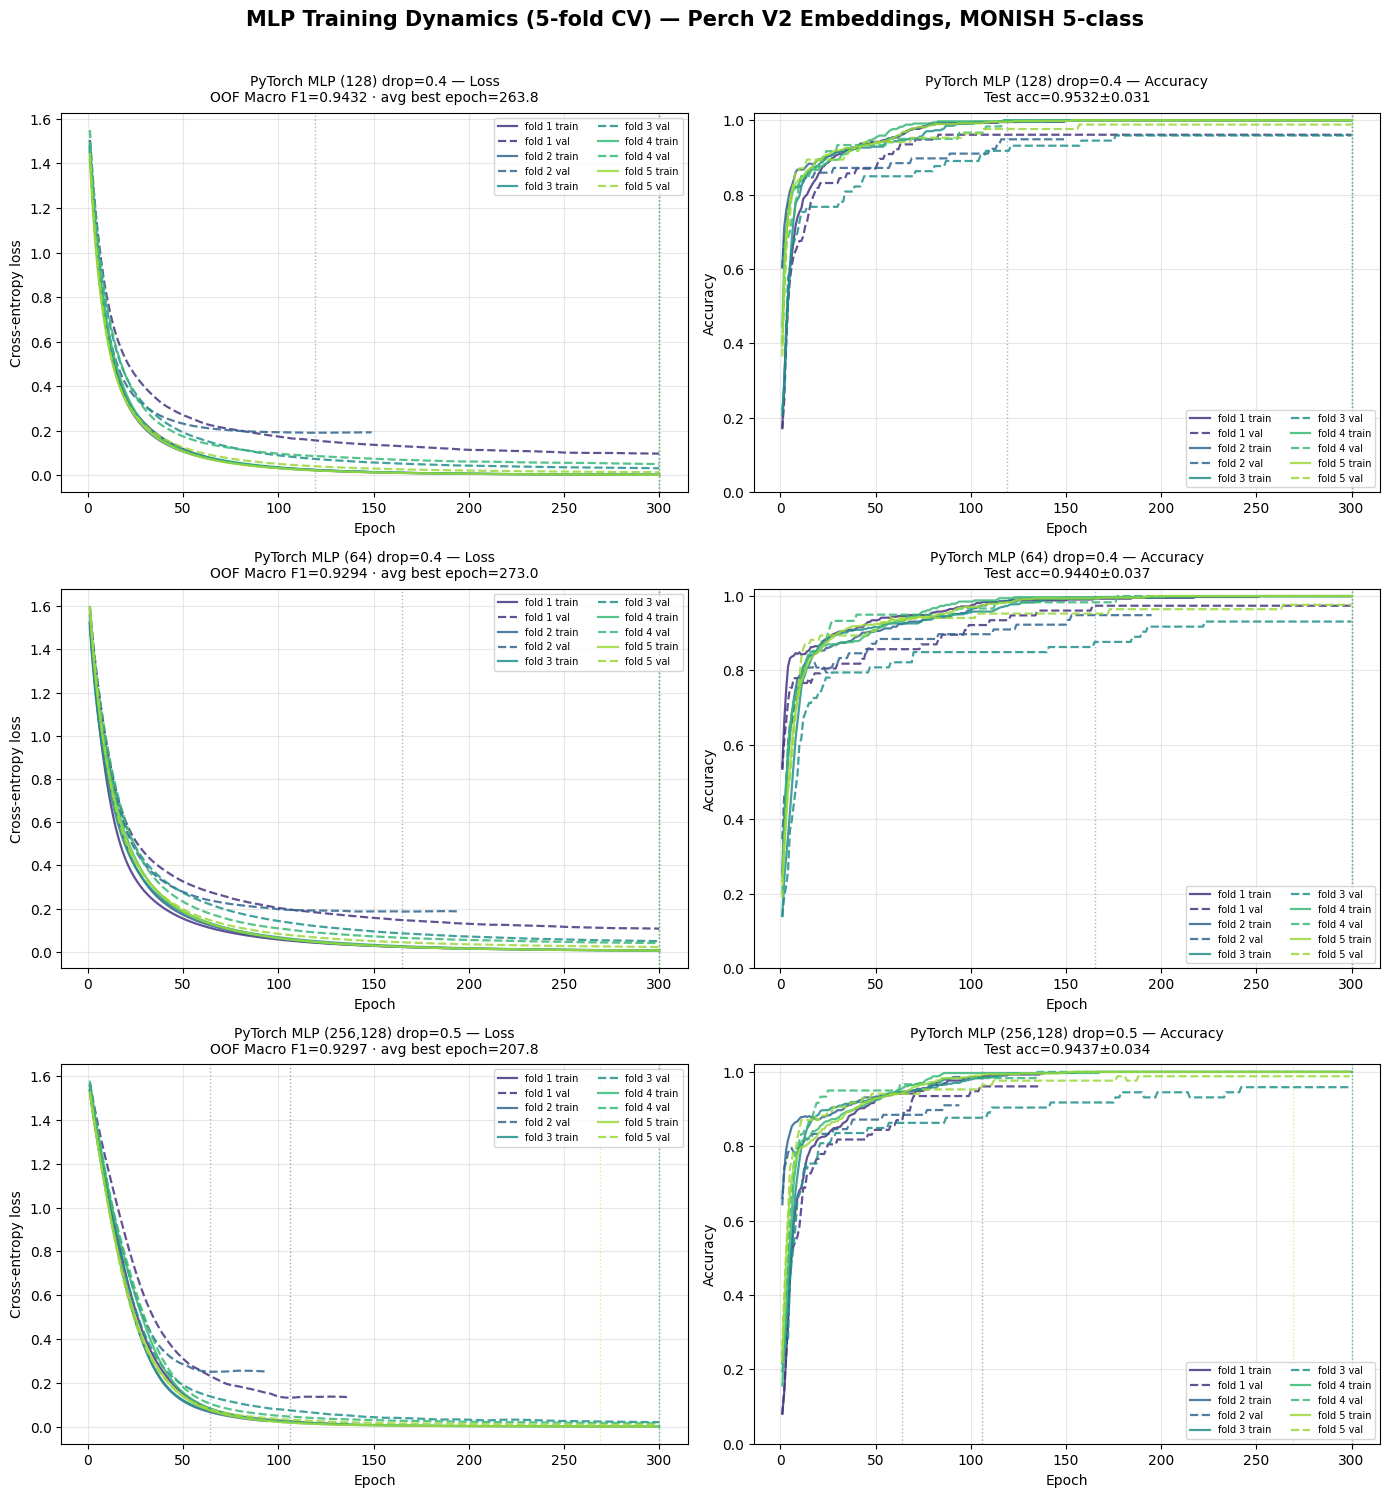

In [30]:
import matplotlib.pyplot as plt
import numpy as np

n_models = len(mlp_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]

fig.suptitle('MLP Training Dynamics (5-fold CV) — Perch V2 Embeddings, MONISH 5-class',
             fontsize=15, fontweight='bold', y=0.995)

# One distinct color per fold, shared across all configs so comparisons line up
fold_cmap = plt.cm.viridis(np.linspace(0.15, 0.85, 5))

for idx, (name, res) in enumerate(mlp_results.items()):
    ax_loss = axes[idx, 0]
    ax_acc  = axes[idx, 1]

    for fc in res['fold_curves']:
        f = fc['fold']
        epochs = np.arange(1, fc['n_iter'] + 1)
        col = fold_cmap[f]

        # Loss
        ax_loss.plot(epochs, fc['train_losses'],
                     color=col, linewidth=1.6, alpha=0.85,
                     label=f'fold {f+1} train')
        ax_loss.plot(epochs, fc['val_losses'],
                     color=col, linewidth=1.6, alpha=0.85, linestyle='--',
                     label=f'fold {f+1} val')
        ax_loss.axvline(fc['best_epoch'], color=col, linestyle=':',
                        alpha=0.45, linewidth=1)

        # Accuracy
        ax_acc.plot(epochs, fc['train_accs'],
                    color=col, linewidth=1.6, alpha=0.85,
                    label=f'fold {f+1} train')
        ax_acc.plot(epochs, fc['val_accs'],
                    color=col, linewidth=1.6, alpha=0.85, linestyle='--',
                    label=f'fold {f+1} val')
        ax_acc.axvline(fc['best_epoch'], color=col, linestyle=':',
                       alpha=0.45, linewidth=1)

    avg_best = np.mean(res['best_epochs_per_fold'])
    ax_loss.set_title(f'{name} — Loss\n'
                      f'OOF Macro F1={res["f1_macro"]:.4f} · avg best epoch={avg_best:.1f}',
                      fontsize=10, pad=8)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Cross-entropy loss')
    ax_loss.legend(fontsize=7, ncol=2, loc='upper right')
    ax_loss.grid(alpha=0.3)

    ax_acc.set_title(f'{name} — Accuracy\n'
                     f'Test acc={res["test_acc_mean"]:.4f}±{res["test_acc_std"]:.3f}',
                     fontsize=10, pad=8)
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=7, ncol=2, loc='lower right')
    ax_acc.grid(alpha=0.3)
    ax_acc.set_ylim(0.0, 1.02)

plt.tight_layout(rect=[0, 0, 1, 0.985])

import os
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/mlp_training_curves_5fold.png',
            dpi=150, bbox_inches='tight')
plt.show()

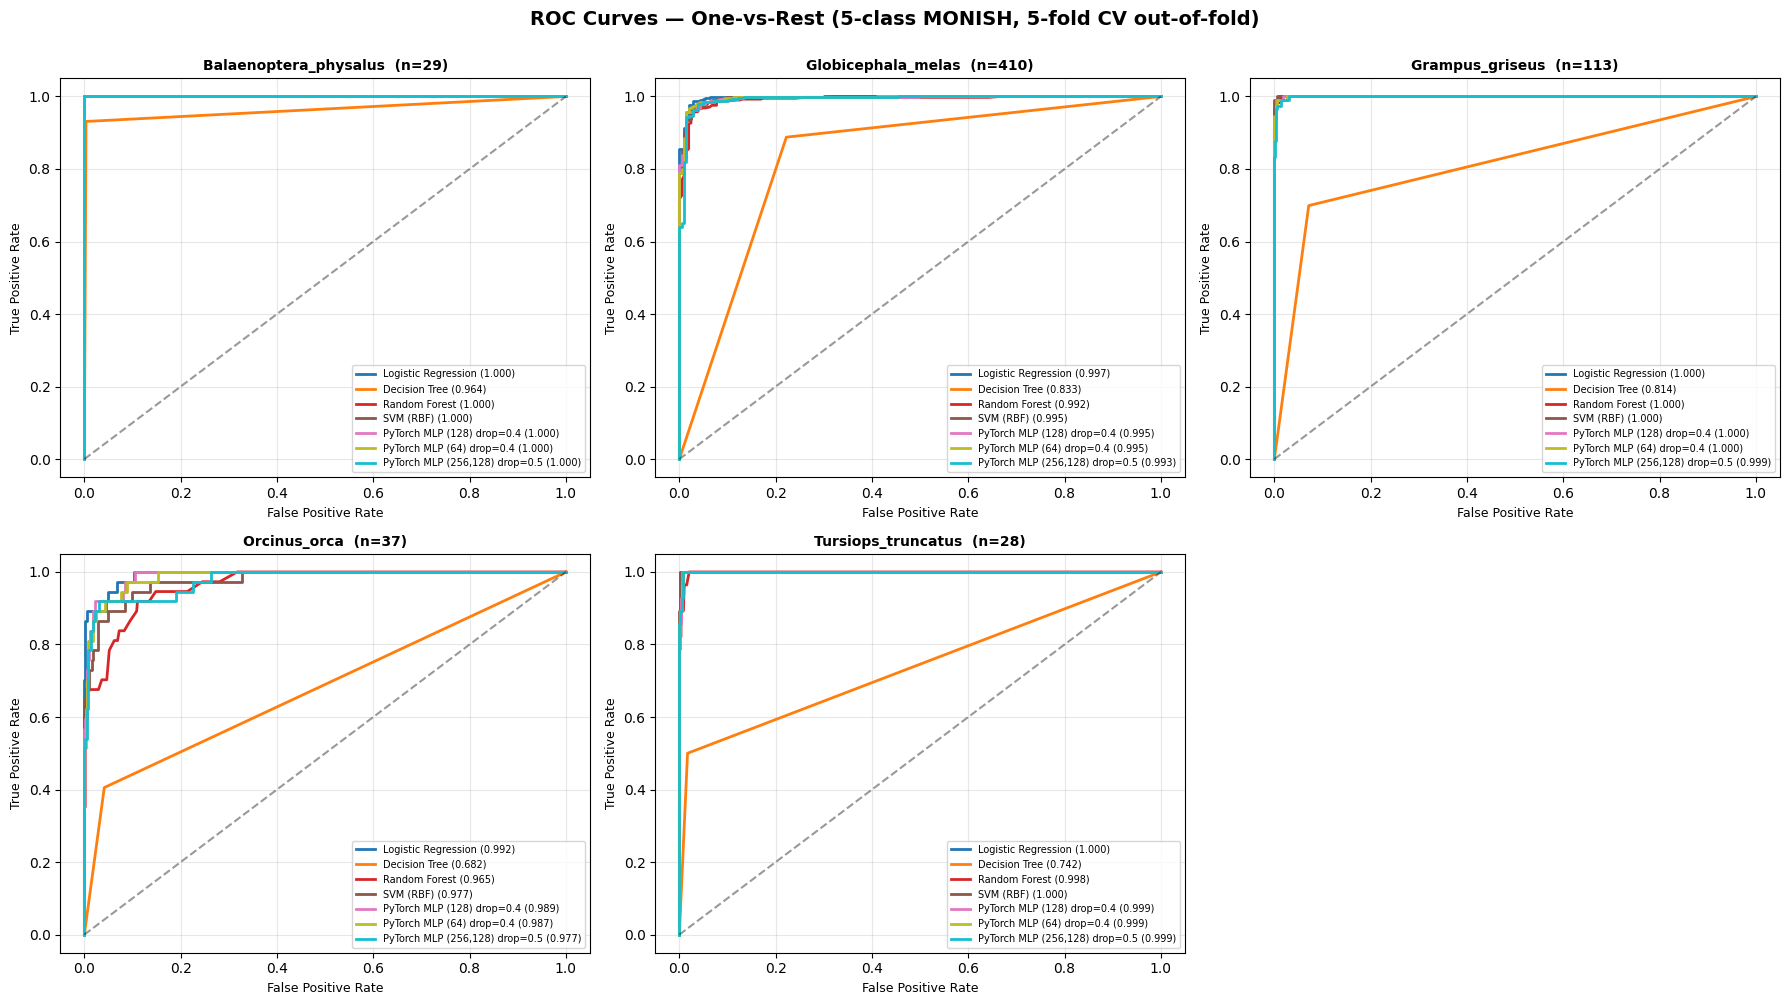

In [31]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score

# All classifiers (sklearn + MLP) trained with 5-fold CV on MONISH 5-class
all_clf = {**results, **mlp_results}

n_classes = len(class_names)
# y_enc holds labels for every sample; oof_proba holds out-of-fold predictions
# from each model, so they're the right basis for "test" ROC.
y_oof_bin = label_binarize(y_enc, classes=range(n_classes))

n_cols = 3
n_rows = int(np.ceil(n_classes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

colors_roc = plt.cm.tab10(np.linspace(0, 1, len(all_clf)))

for class_idx, cn in enumerate(class_names):
    ax = axes[class_idx]
    for model_idx, (name, res) in enumerate(all_clf.items()):
        proba = res['oof_proba']
        # Some samples might have NaN proba if a fold somehow failed; mask them
        mask = ~np.isnan(proba[:, class_idx])
        y_true_c = y_oof_bin[mask, class_idx]
        y_score_c = proba[mask, class_idx]

        fpr, tpr, _ = roc_curve(y_true_c, y_score_c)
        try:
            auc = roc_auc_score(y_true_c, y_score_c)
            label = f'{name} ({auc:.3f})'
        except ValueError:
            label = f'{name} (n/a)'
        ax.plot(fpr, tpr, label=label,
                color=colors_roc[model_idx], linewidth=2)

    n_pos = int(y_oof_bin[:, class_idx].sum())
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.set_title(f'{cn}  (n={n_pos})', fontsize=10, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(alpha=0.3)

for j in range(n_classes, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ROC Curves — One-vs-Rest (5-class MONISH, 5-fold CV out-of-fold)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/roc_curves_5class_cv.png',
             dpi=150, bbox_inches='tight')
plt.show()

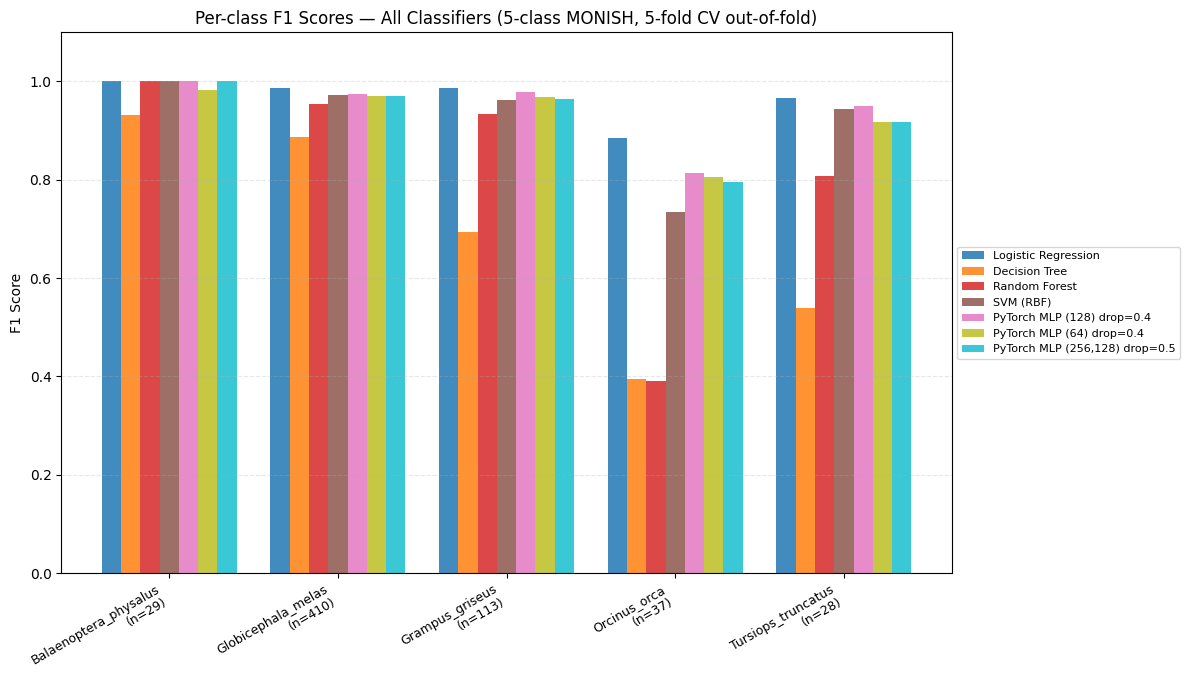

In [32]:
#@title Per-class F1 comparison bar chart — 5-class MONISH (5-fold CV, out-of-fold)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

all_clf = {**results, **mlp_results}

n_clf = len(all_clf)
n_cls = len(class_names)

cmap = plt.cm.tab10 if n_clf <= 10 else plt.cm.tab20
colors = cmap(np.linspace(0, 1, min(n_clf, cmap.N)))

x = np.arange(n_cls)
width = 0.8 / n_clf

fig, ax = plt.subplots(figsize=(max(12, n_cls * 1.6), 7))

for i, (name, res) in enumerate(all_clf.items()):
    f1_per = res['f1_per_class']
    offset = (i - n_clf / 2 + 0.5) * width
    ax.bar(x + offset, f1_per, width, label=name,
           color=colors[i % len(colors)], alpha=0.85)

# Support = full dataset size per class (OOF covers every sample)
oof_support = np.bincount(y_enc, minlength=n_cls)
xtick_labels = [f'{cn}\n(n={s})' for cn, s in zip(class_names, oof_support)]

ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('Per-class F1 Scores — All Classifiers (5-class MONISH, 5-fold CV out-of-fold)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/f1_comparison_all_classifiers_monish.png',
            dpi=150, bbox_inches='tight')
plt.show()

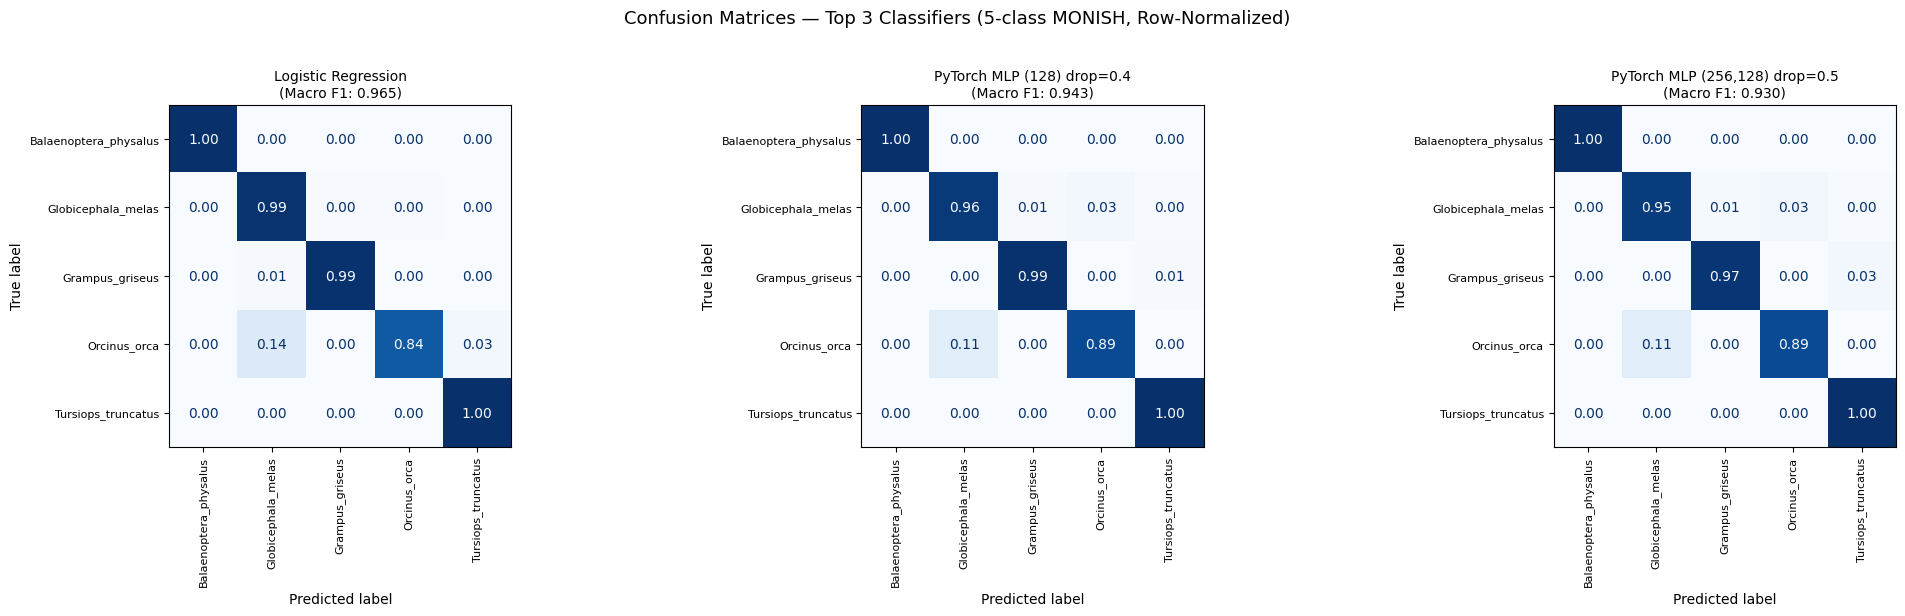

In [33]:
#@title Confusion matrices — Top N classifiers by Macro F1 (5-class MONISH)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

TOP_N = 3

# Combine results from both sklearn models and PyTorch MLPs
all_clf = {**results} # mlp_results are already merged into results in your previous cell
top_clf = sorted(all_clf.items(), key=lambda x: x[1]['f1_macro'], reverse=True)[:TOP_N]

fig, axes = plt.subplots(1, TOP_N, figsize=(7 * TOP_N, 6))
if TOP_N == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, top_clf):
    ConfusionMatrixDisplay.from_predictions(
        y_enc,                  # Use the encoded ground truth used in CV
        res['oof_pred'],        # Use Out-Of-Fold predictions
        display_labels=class_names,
        ax=ax, 
        colorbar=False, 
        xticks_rotation='vertical', 
        cmap='Blues',
        normalize='true',       # Row-normalized: shows recall per class
        values_format='.2f',
    )
    ax.set_title(f'{name}\n(Macro F1: {res["f1_macro"]:.3f})', fontsize=10)
    ax.tick_params(labelsize=8)

plt.suptitle(f'Confusion Matrices — Top {TOP_N} Classifiers (5-class MONISH, Row-Normalized)',
             fontsize=13, y=1.02)
plt.tight_layout()

# Save results
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/confusion_matrices_top{TOP_N}_monish.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [34]:
#@title Save full results to CSV — ALL classifiers (5-class MONISH)
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd
import os

# Combine results (mlp_results was already merged into results in the previous step)
all_clf = {**results} 

rows = []
for name, res in all_clf.items():
    # Use the OOF probabilities and predictions stored during CV
    y_pred_all = res['oof_pred']
    y_proba_all = res['oof_proba']
    
    # Per-class metrics using the full dataset ground truth (y_enc)
    p, r, f, s = precision_recall_fscore_support(
        y_enc, y_pred_all, labels=range(len(class_names)), zero_division=0
    )
    
    row = {
        'classifier': name,
        'macro_f1': res['f1_macro'],
        'roc_auc_ovr': res.get('auc_ovr'), # Pulling pre-calculated AUC from the dict
        'train_acc_mean': res.get('train_acc_mean'),
        'test_acc_mean': res.get('test_acc_mean'),
        'time_seconds': res.get('time_s', None),
    }
    
    # Add per-class precision, recall, and f1
    for i, cls in enumerate(class_names):
        row[f'{cls}_f1']        = round(f[i], 3)
        row[f'{cls}_precision'] = round(p[i], 3)
        row[f'{cls}_recall']    = round(r[i], 3)
        row[f'{cls}_support']   = s[i]
        
    rows.append(row)

results_df = pd.DataFrame(rows)

# Reorder columns for better readability
priority_cols = ['classifier', 'macro_f1', 'roc_auc_ovr', 'train_acc_mean', 'test_acc_mean', 'time_seconds']
other_cols = [c for c in results_df.columns if c not in priority_cols]
results_df = results_df[priority_cols + other_cols].sort_values('macro_f1', ascending=False).reset_index(drop=True)

# Save to CSV
os.makedirs(save_dir, exist_ok=True)
csv_path = f'{save_dir}/perch_v2_all_classifiers_results_monish.csv'
results_df.to_csv(csv_path, index=False)

print(f'Saved results for {len(results_df)} classifiers to {csv_path}')
display(results_df.round(3))

Saved results for 7 classifiers to /data2/mromaniuc/cet-det/models/perch_v2/MONISH/perch_v2_all_classifiers_results_monish.csv


,classifier,macro_f1,roc_auc_ovr,train_acc_mean,test_acc_mean,time_seconds,Balaenoptera_physalus_f1,Balaenoptera_physalus_precision,Balaenoptera_physalus_recall,Balaenoptera_physalus_support,...,Grampus_griseus_recall,Grampus_griseus_support,Orcinus_orca_f1,Orcinus_orca_precision,Orcinus_orca_recall,Orcinus_orca_support,Tursiops_truncatus_f1,Tursiops_truncatus_precision,Tursiops_truncatus_recall,Tursiops_truncatus_support
0,Logistic Regression,0.965,0.997,1.000,0.971,0.476,1.000,1.000,1.000,29,...,0.991,113,0.886,0.939,0.838,37,0.966,0.933,1.000,28
1,PyTorch MLP (128) drop=0.4,0.943,0.996,0.999,0.953,8.035,1.000,1.000,1.000,29,...,0.991,113,0.815,0.750,0.892,37,0.949,0.903,1.000,28
2,"PyTorch MLP (256,128) drop=0.5",0.930,0.994,0.987,0.944,6.899,1.000,1.000,1.000,29,...,0.973,113,0.795,0.717,0.892,37,0.918,0.848,1.000,28
3,PyTorch MLP (64) drop=0.4,0.929,0.996,0.999,0.944,8.805,0.983,0.967,1.000,29,...,0.982,113,0.805,0.733,0.892,37,0.918,0.848,1.000,28
4,SVM (RBF),0.923,0.996,0.998,0.946,4.138,1.000,1.000,1.000,29,...,1.000,113,0.735,0.806,0.676,37,0.943,1.000,0.893,28
5,Random Forest,0.817,0.992,1.000,0.897,6.362,1.000,1.000,1.000,29,...,0.929,113,0.391,1.000,0.243,37,0.809,1.000,0.679,28
6,Decision Tree,0.689,0.822,1.000,0.785,2.188,0.931,0.931,0.931,29,...,0.699,113,0.395,0.385,0.405,37,0.538,0.583,0.500,28


# 5-classs dimensionality reduction

Running full PCA...

Total components: 617

PCA Variance Explained (first 30 components):
Component  Variance Explained (%)  Cumulative (%)
      PC1                 10.8855         10.8855
      PC2                  6.9188         17.8042
      PC3                  5.6244         23.4286
      PC4                  3.9127         27.3414
      PC5                  3.3526         30.6939
      PC6                  2.8260         33.5200
      PC7                  2.6057         36.1256
      PC8                  2.0291         38.1547
      PC9                  1.9593         40.1141
     PC10                  1.8302         41.9443
     PC11                  1.5072         43.4515
     PC12                  1.4084         44.8600
     PC13                  1.3793         46.2393
     PC14                  1.3169         47.5562
     PC15                  1.2716         48.8278
     PC16                  1.2100         50.0379
     PC17                  1.1444         51.1823
     PC18 

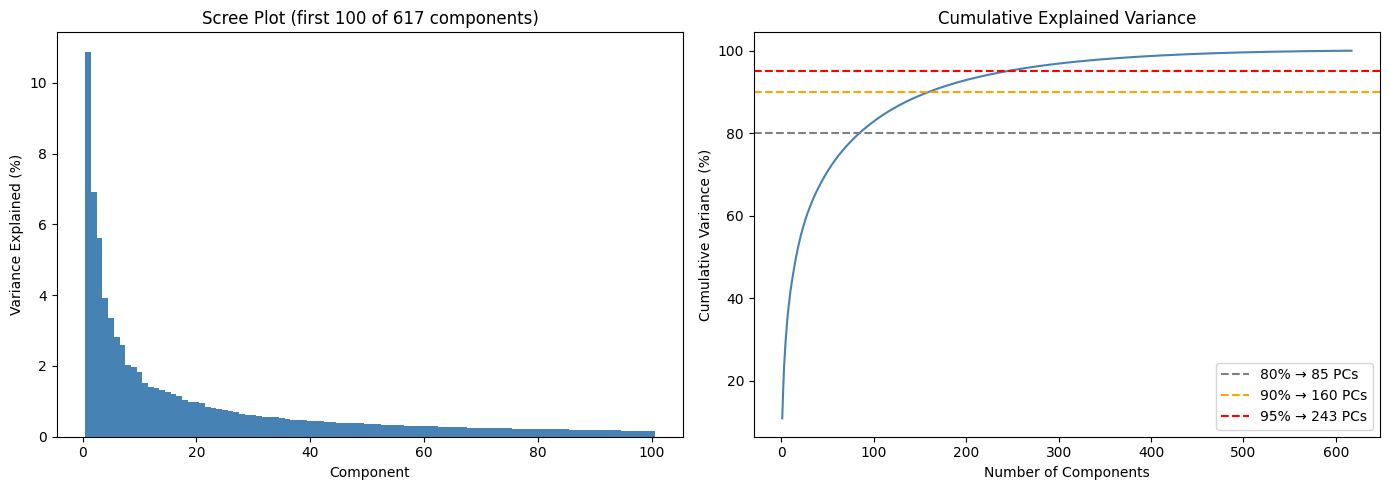

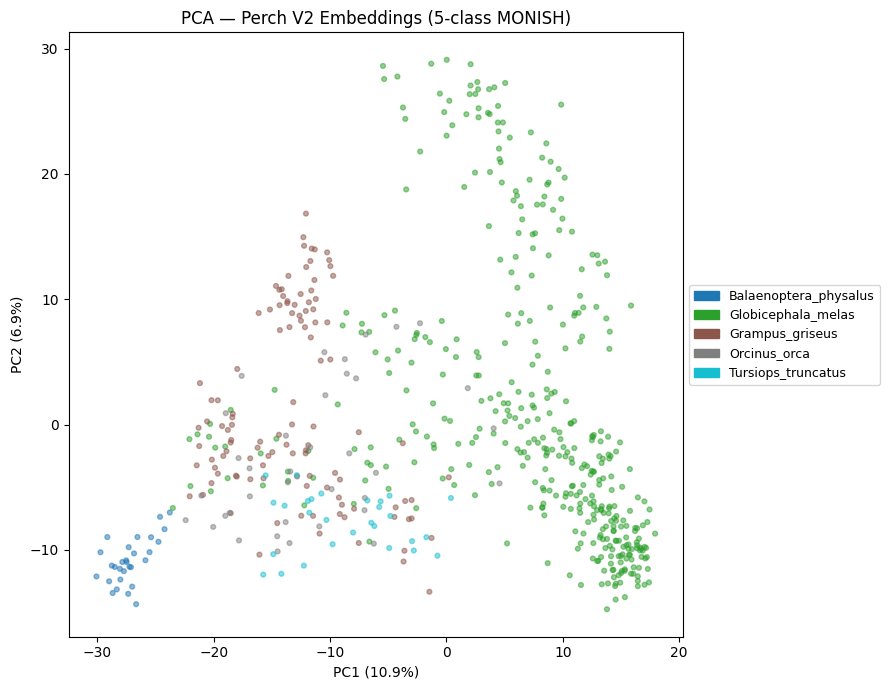


PCA-reduced shape for t-SNE/UMAP input: (617, 160)

Running t-SNE with multiple distance metrics...
  t-SNE metric: euclidean...
  t-SNE metric: cosine...
  t-SNE metric: manhattan...
  t-SNE metric: correlation...


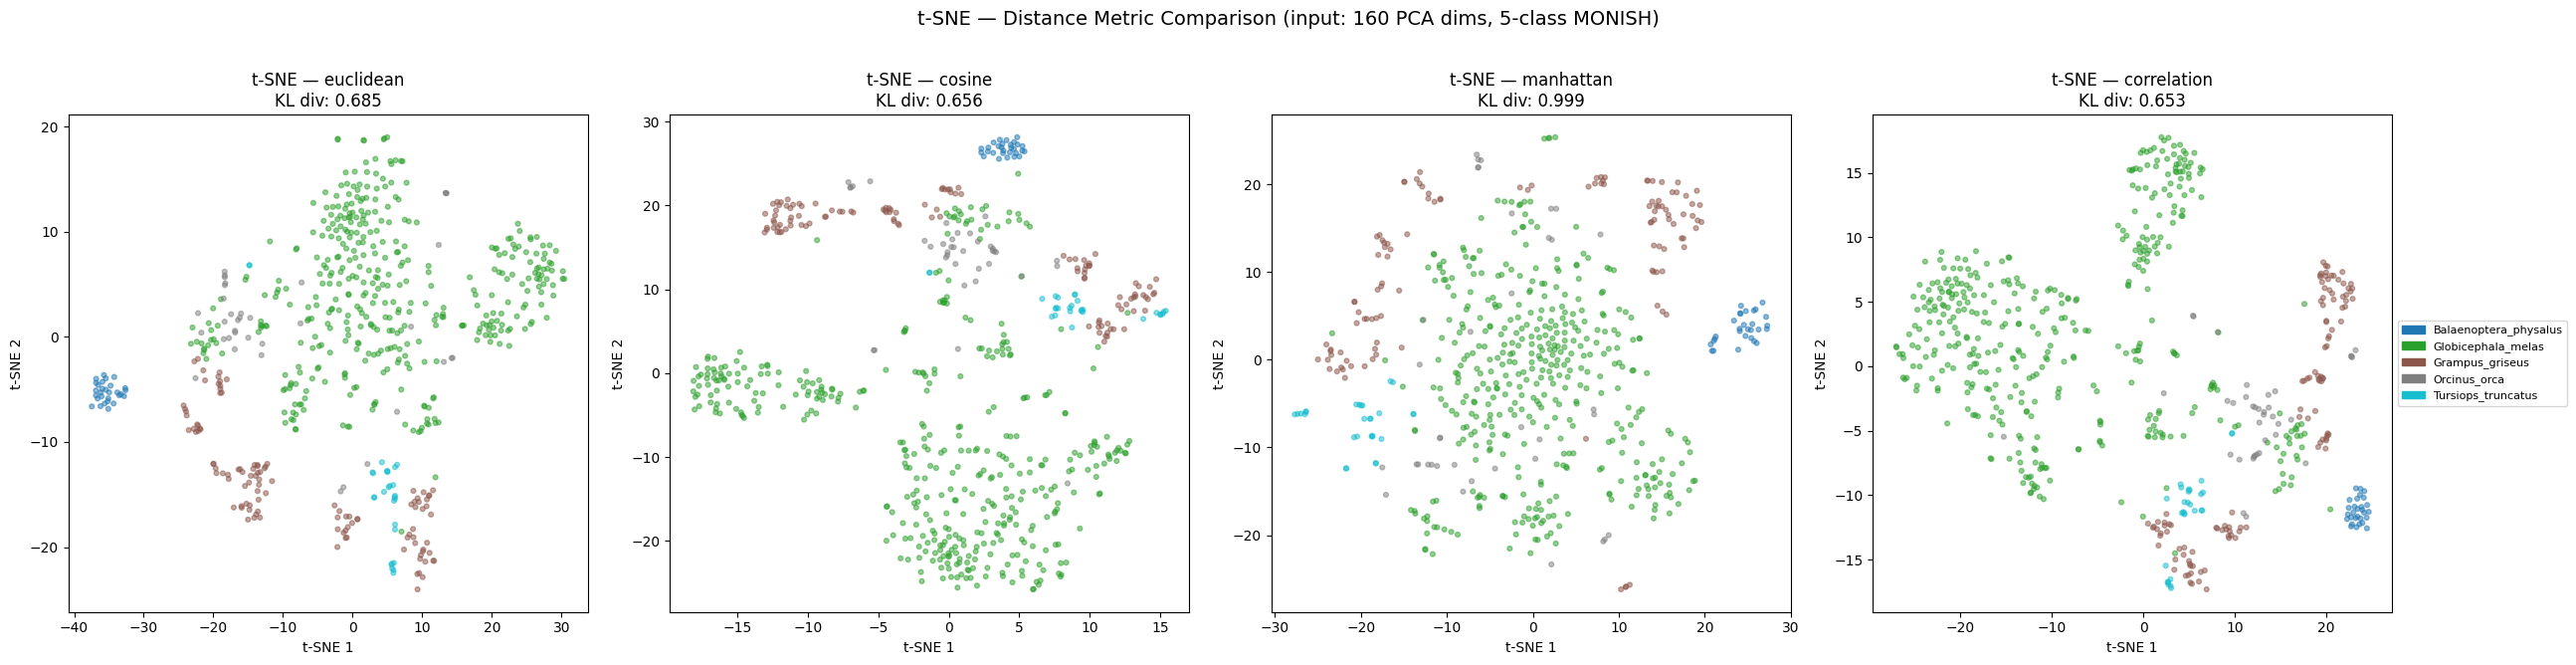


Running UMAP with multiple distance metrics...
  UMAP metric: euclidean...
  UMAP metric: cosine...
  UMAP metric: manhattan...
  UMAP metric: correlation...


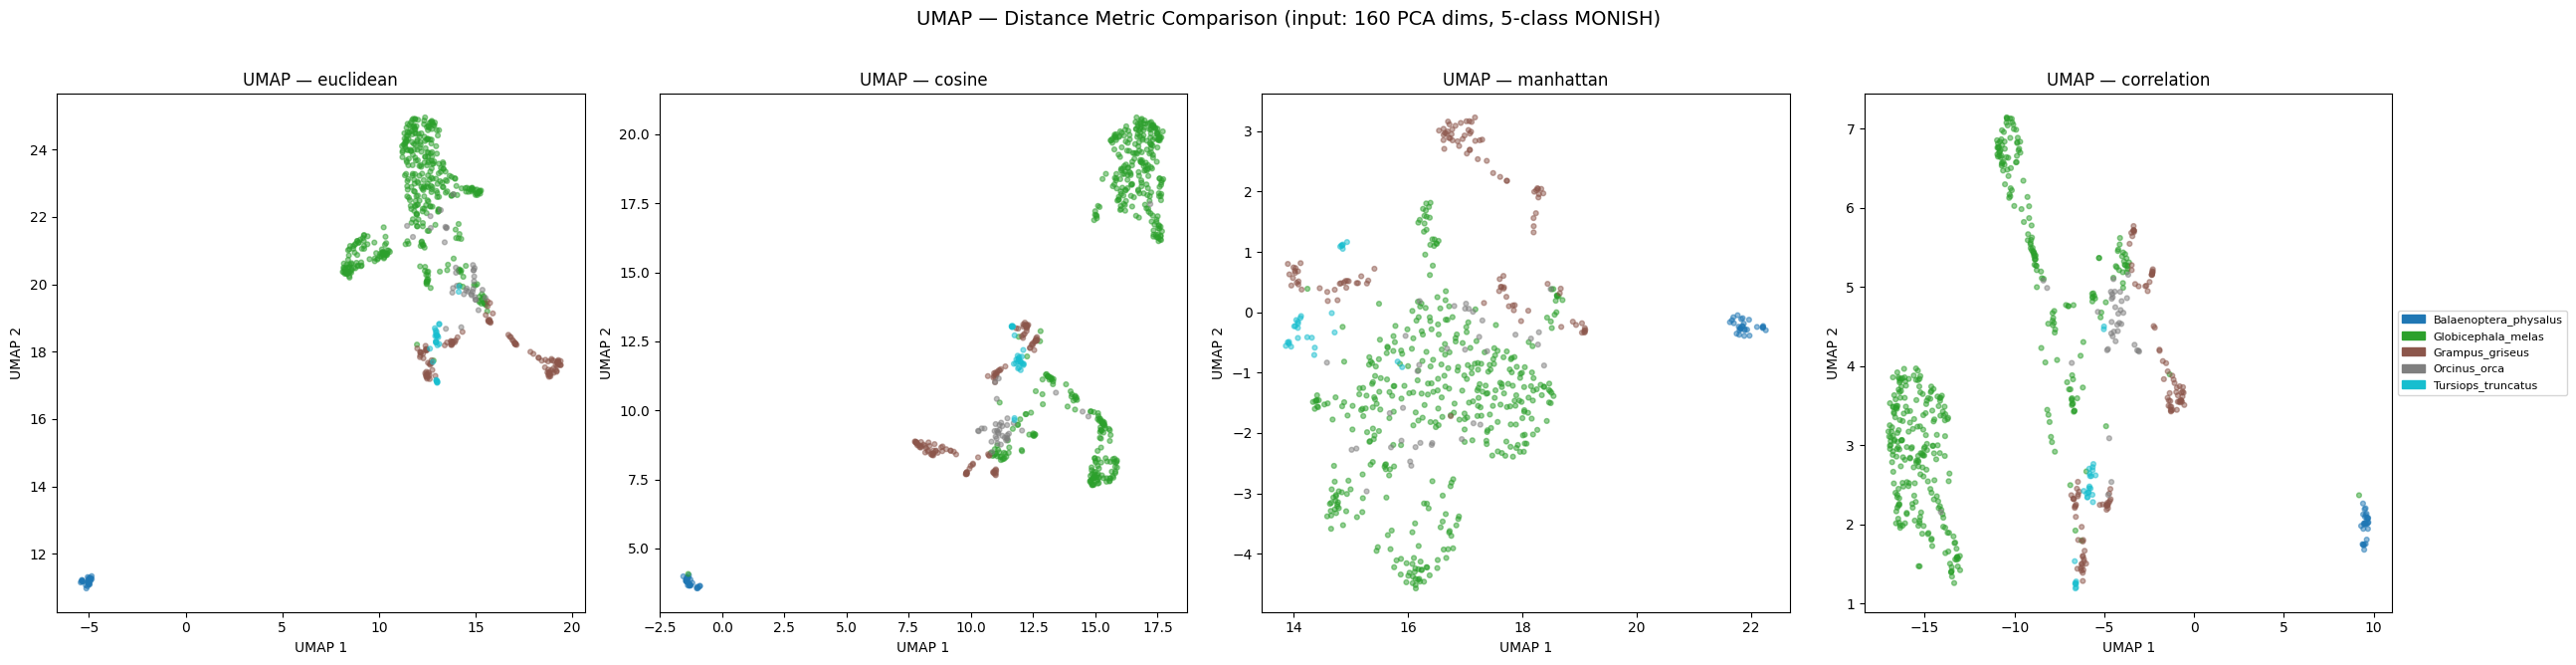


SUMMARY
PCA input dims: 1536 → reduced to 160 (90% variance)

t-SNE KL Divergence by metric (lower = better fit):
  correlation      KL: 0.6526
  cosine           KL: 0.6563
  euclidean        KL: 0.6853
  manhattan        KL: 0.9992

All coordinates saved with _monish suffix.


In [35]:
#@title Dimensionality reduction — PCA + t-SNE & UMAP (5-class MONISH)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Standardize embeddings
scaler_viz = StandardScaler()
X_scaled = scaler_viz.fit_transform(X_clean)

# Color setup — Dynamically handles your 5 species
species_list = sorted(np.unique(y_clean))
tab_colors = plt.cm.tab10(np.linspace(0, 1, len(species_list)))
colors_map = {sp: tab_colors[i] for i, sp in enumerate(species_list)}
c = np.array([colors_map[label] for label in y_clean])
alpha = 0.5
s = 12
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items()]

os.makedirs(f'{save_dir}/dim_red', exist_ok=True)

# ═══════════════════════════════════════════════════════════════════════════════
# 1. FULL PCA — Variance analysis
# ═══════════════════════════════════════════════════════════════════════════════
print('Running full PCA...')
pca_full = PCA(random_state=random_seed)
pca_full.fit(X_scaled)

n_total = len(pca_full.explained_variance_ratio_)
cumvar_full = np.cumsum(pca_full.explained_variance_ratio_) * 100

var_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(n_total)],
    'Variance Explained (%)': pca_full.explained_variance_ratio_ * 100,
    'Cumulative (%)': cumvar_full
})

print(f'\nTotal components: {n_total}')
print(f'\nPCA Variance Explained (first 30 components):')
print(var_df.head(30).to_string(index=False, float_format='%.4f'))

n80 = int(np.argmax(cumvar_full >= 80) + 1)
n90 = int(np.argmax(cumvar_full >= 90) + 1)
n95 = int(np.argmax(cumvar_full >= 95) + 1)
n99 = int(np.argmax(cumvar_full >= 99) + 1)
print(f'\nComponents for 80% variance: {n80}')
print(f'Components for 90% variance: {n90}')
print(f'Components for 95% variance: {n95}')
print(f'Components for 99% variance: {n99}')

n_pca = n90
print(f'\n→ Using {n_pca} PCA components for t-SNE/UMAP input (90% variance)')

# Scree + cumulative
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
n_show = min(100, n_total)
ax1.bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show] * 100,
        color='steelblue', width=1.0)
ax1.set_xlabel('Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title(f'Scree Plot (first {n_show} of {n_total} components)')

ax2.plot(range(1, n_total + 1), cumvar_full, color='steelblue')
ax2.axhline(80, color='gray',   linestyle='--', label=f'80% → {n80} PCs')
ax2.axhline(90, color='orange', linestyle='--', label=f'90% → {n90} PCs')
ax2.axhline(95, color='red',    linestyle='--', label=f'95% → {n95} PCs')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_full_variance_monish.png', dpi=150)
plt.show()

# PCA 2D scatter
pca2 = PCA(n_components=2, random_state=random_seed)
X_pca2 = pca2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=c, alpha=alpha, s=s)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — Perch V2 Embeddings (5-class MONISH)')
ax.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_2d_monish.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 2. PCA-reduce for t-SNE and UMAP input
# ═══════════════════════════════════════════════════════════════════════════════
pca_red = PCA(n_components=n_pca, random_state=random_seed)
X_pca_red = pca_red.fit_transform(X_scaled)
print(f'\nPCA-reduced shape for t-SNE/UMAP input: {X_pca_red.shape}')

# ═══════════════════════════════════════════════════════════════════════════════
# 3. t-SNE — Multiple distance metrics
# ═══════════════════════════════════════════════════════════════════════════════
metrics = ['euclidean', 'cosine', 'manhattan', 'correlation']

print('\nRunning t-SNE with multiple distance metrics...')
fig, axes = plt.subplots(1, 4, figsize=(26, 6.5))
tsne_results = {}

for ax, metric in zip(axes, metrics):
    print(f'  t-SNE metric: {metric}...')
    tsne = TSNE(
        n_components=2,
        perplexity=40,
        learning_rate='auto',
        init='random' if metric != 'euclidean' else 'pca',
        max_iter=1000,
        metric=metric,
        random_state=random_seed,
        verbose=0
    )
    X_tsne = tsne.fit_transform(X_pca_red)
    tsne_results[metric] = {'coords': X_tsne, 'kl': tsne.kl_divergence_}

    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f't-SNE — {metric}\nKL div: {tsne.kl_divergence_:.3f}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

axes[-1].legend(handles=legend_patches, loc='center left',
                bbox_to_anchor=(1, 0.5), fontsize=8)

plt.suptitle(f't-SNE — Distance Metric Comparison '
             f'(input: {n_pca} PCA dims, 5-class MONISH)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/tsne_metrics_comparison_monish.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 4. UMAP — Multiple distance metrics
# ═══════════════════════════════════════════════════════════════════════════════
print('\nRunning UMAP with multiple distance metrics...')
try:
    import umap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'umap-learn', '-q'])
    import umap

fig, axes = plt.subplots(1, 4, figsize=(26, 6.5))
umap_results = {}

for ax, metric in zip(axes, metrics):
    print(f'  UMAP metric: {metric}...')
    reducer = umap.UMAP(
        n_neighbors=30,
        min_dist=0.1,
        n_components=2,
        metric=metric,
        random_state=random_seed,
        verbose=False
    )
    X_umap = reducer.fit_transform(X_pca_red)
    umap_results[metric] = X_umap

    ax.scatter(X_umap[:, 0], X_umap[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f'UMAP — {metric}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

axes[-1].legend(handles=legend_patches, loc='center left',
                bbox_to_anchor=(1, 0.5), fontsize=8)

plt.suptitle(f'UMAP — Distance Metric Comparison '
             f'(input: {n_pca} PCA dims, 5-class MONISH)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/umap_metrics_comparison_monish.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 5. Summary + save coords
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'PCA input dims: {X_scaled.shape[1]} → reduced to {n_pca} (90% variance)')
print(f'\nt-SNE KL Divergence by metric (lower = better fit):')
for metric, data in sorted(tsne_results.items(), key=lambda x: x[1]['kl']):
    print(f'  {metric:15s}  KL: {data["kl"]:.4f}')

np.save(f'{save_dir}/dim_red/coords_pca2_monish.npy', X_pca2)
for metric in metrics:
    np.save(f'{save_dir}/dim_red/coords_tsne_{metric}_monish.npy',
            tsne_results[metric]['coords'])
    np.save(f'{save_dir}/dim_red/coords_umap_{metric}_monish.npy',
            umap_results[metric])
print('\nAll coordinates saved with _monish suffix.')

In [36]:
#@title Quantitative quality metrics

from sklearn.metrics import silhouette_score
from sklearn.manifold import trustworthiness

print('\n' + '=' * 80)
print('QUANTITATIVE QUALITY METRIC')
print('=' * 80)
print(f'{"Method":<20} {"Metric":<15} {"Trustworthiness":>16} {"Silhouette":>12}')
print('-' * 80)

# Use actual 5-class labels (encoded as ints for silhouette)
le_viz = LabelEncoder()
y_viz = le_viz.fit_transform(y_clean)

# t-SNE quality
for metric, data in tsne_results.items():
    trust = trustworthiness(X_pca_red, data['coords'], n_neighbors=15)
    sil = silhouette_score(data['coords'], y_viz)
    print(f'{"t-SNE":<20} {metric:<15} {trust:>16.4f} {sil:>12.4f}')

print()

# UMAP quality
for metric, coords in umap_results.items():
    trust = trustworthiness(X_pca_red, coords, n_neighbors=15)
    sil = silhouette_score(coords, y_viz)
    print(f'{"UMAP":<20} {metric:<15} {trust:>16.4f} {sil:>12.4f}')

print()

# PCA baseline
trust_pca = trustworthiness(X_pca_red, X_pca2, n_neighbors=15)
sil_pca = silhouette_score(X_pca2, y_viz)
print(f'{"PCA (2D)":<20} {"euclidean":<15} {trust_pca:>16.4f} {sil_pca:>12.4f}')


QUANTITATIVE QUALITY METRIC
Method               Metric           Trustworthiness   Silhouette
--------------------------------------------------------------------------------
t-SNE                euclidean                 0.9392       0.1051
t-SNE                cosine                    0.9413       0.1226
t-SNE                manhattan                 0.8832       0.0653
t-SNE                correlation               0.9416       0.1190

UMAP                 euclidean                 0.9231       0.1605
UMAP                 cosine                    0.9346       0.0432
UMAP                 manhattan                 0.8876      -0.0112
UMAP                 correlation               0.9332       0.1719

PCA (2D)             euclidean                 0.8036       0.1493
